# Анализ лояльности пользователей Яндекс Афиши

- Автор: Пучкова Анастасия
- Дата: 10.02.2026

### Цели и задачи проекта
Необходимо привлечь новых пользователей, удержать их и превратить в постоянных. Для этого нужно повысить долю клиентов, которые после одной покупки приходят снова и совершают новые.
Исследовательский анализ поможет лучше понять поведение пользователей, какие люди с большей вероятностью возвращаются на платформу и делают заказы повторно.

Это позволит:
* Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
* Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
* Оптимизировать маркетинговые бюджеты.
* Повысить общий уровень удержания клиентов.

### Содержимое проекта

**Шаг 1.** Загрузка данных и их предобработка

**Шаг 2.** Предобработка данных

**Шаг 3.** Создание профиля пользователя

**Шаг 4.** Исследовательский анализ данных

**Шаг 5.** Общие выводы и рекомендации

## Этапы выполнения проекта

### 1. Загрузка данных и их предобработка

---

- `user_id` — уникальный идентификатор пользователя, совершившего заказ;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (`mobile` — мобильные устройства, `desktop` — стационарные);
- `order_id` — уникальный идентификатор заказа;
- `order_dt` — дата создания заказа (используйте данные `created_dt_msk`);
- `order_ts` — дата и время создания заказа (используйте данные `created_ts_msk`);
- `currency_code` — валюта оплаты;
- `revenue` — выручка от заказа;
- `tickets_count` — количество купленных билетов;
- `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
- `event_id` — уникальный идентификатор мероприятия;
- `service_name` — название билетного оператора;
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
- `region_name` — название региона, в котором прошло мероприятие;
- `city_name` — название города, в котором прошло мероприятие.

---


In [1]:
import pandas as pd
from sqlalchemy import create_engine

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

!pip install phik -q
from phik import phik_matrix

from sqlalchemy import create_engine

In [2]:
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             }

In [3]:
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

In [4]:
engine = create_engine(connection_string)

In [5]:
query = '''
-- Настройка параметра synchronize_seqscans важна для проверки
WITH set_config_precode AS (
  SELECT set_config('synchronize_seqscans', 'off', true)
)

-- Напишите ваш запрос ниже
SELECT user_id,
  p.device_type_canonical,
  p.order_id,
  p.created_dt_msk AS order_dt,
  p.created_ts_msk AS order_ts,
  p.currency_code,
  p.revenue,
  p.tickets_count,
  p.created_dt_msk::date - LAG(p.created_dt_msk::date) OVER (PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev,
  e.event_id,
  e.event_name_code AS event_name,
  e.event_type_main,
  p.service_name,
  r.region_name,
  c.city_name
FROM afisha.purchases AS p
INNER JOIN afisha.events AS e ON p.event_id = e.event_id
LEFT JOIN afisha.city AS c ON e.city_id = c.city_id
LEFT JOIN afisha.regions AS r ON c.region_id = r.region_id
WHERE device_type_canonical IN ('mobile','desktop') AND e.event_type_main != 'фильм'
ORDER BY user_id;
'''

In [6]:
df = pd.read_sql_query(query, con=engine)

**Промежуточный вывод:**

Написан SQL-запрос, в котором собрана вся небходимая информация для анализа лояльности пользователей Яндекс Афиши. Далее посмотрим из каких столбцов он состоит:

---

**1.2:** Общая информацию о выгруженных данных.

---

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

In [8]:
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


In [9]:
rows_before = df.shape[0]
cols_before = df.shape[1]

**Промежуточный вывод:**
* После написания SQL-запроса, получился датафрейм, в котором 15 колонок и 290611 строк, в нем представлены данные пользователей Яндекс Афиши. Данные занимают 33.3+ MB.
* Пропуски встречаются только в столбце `days_since_prev`. Он показывает, сколько дней, прошло между предыдущей и текущей покупками пользователя. NULL означает, что у пользователя только одна покупка, первый заказ и, соответственно, предыдущей даты для расчёта интервала просто нет..
* Столбцы носят корректные названия, подходящие для анализа данных, приведены в нижнему регистру и к единому виду - snake case.
* Представленные данные хранятся в: object, int64, float64 и datetime64[ns]. Носят корректный тип данных.
* Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

* При преобработке данных необходимо создать столбец `revenue_rub`, в котором будут хранниться данные о выручке сервиса только в российских рублях. Необходимо изучить пропуски и типы данных столбцов, order_dt преобразовать в тип - data и сократить размерность некоторых столбцов.

---

###  2. Предобработка данных



---


In [10]:
tenge_rate_url = 'https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv'
tenge_rate_df = pd.read_csv(tenge_rate_url)

In [11]:
tenge_rate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [12]:
tenge_rate_df.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [13]:
tenge_rate_df['data'] = pd.to_datetime(tenge_rate_df['data'])
df['order_dt'] = df['order_dt'].dt.date

In [14]:
tenge_rate_mean = tenge_rate_df['curs'].mean()
print(tenge_rate_mean)

19.75581792717087


In [15]:
rate_dict = dict(zip(tenge_rate_df['data'], tenge_rate_df['curs']))

def convert_to_rub(row):
    if row['currency_code'] == 'kzt':
        curs = rate_dict.get(row['order_dt'])
        if curs is not None:
            return row['revenue'] * (curs / 100)
        else:
            return row['revenue'] * (tenge_rate_mean / 100)
    else:
        return row['revenue']

df['revenue_rub'] = df.apply(convert_to_rub, axis=1)

* В датасете `final_tickets_tenge_df.csv` хранится информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год, 357 строк, нет пропусков и занимает 11.3+ KB. По выводу видно, что столбец `data` имеет тип данных object, поэтому преобразовали его в datetime.
* Строк в датасете `final_tickets_tenge_df.csv` 357, в датафрейме, который мы создали с помощью SQL-запроса из базы данных `data-analyst-afisha` - 290611. Поэтому оставшиеся пропуски мы заменили средним курсом.

In [16]:
def show_missing_stats(temp0):
    missing_stats = pd.DataFrame({
        'Количество пропусков': temp0.isnull().sum(),
        'Доля пропусков': temp0.isnull().mean()
    })
    missing_stats = missing_stats[missing_stats['Количество пропусков'] > 0]

    if missing_stats.empty:
        return 'Пропусков в данных нет'

    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Количество пропусков,Доля пропусков
days_since_prev,21933,0.0755


Пропуски оставим в датафрейме, чтобы понимать, какой из пользоватлей и когда сделал первый заказ.

In [17]:
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='unsigned')
df['order_id'] = pd.to_numeric(df['order_id'], downcast='unsigned')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='unsigned')
df['revenue'] = df['revenue'].astype('float32')

Сократили разрядность, так как целые числа всегда положительные, вещественные, чтобы занимали меньше места в памяти, так как в данной работе там не так важно иметь много цифр ппосле запятой, не будет точных денежных расчетов и тд.

In [18]:
df['revenue_rub'].describe()

count    290611.000000
mean        555.668249
std         875.469763
min         -90.760000
25%         113.970000
50%         351.870000
75%         802.050000
max       81174.540000
Name: revenue_rub, dtype: float64

В столбце revenue_rub, в котором хранится информация о выручке сервиса представленая в российских рублях, обнаружены отрицательные значени, посмотрим сколько таких записей:

In [19]:
negative_count = (df['revenue_rub']<0).sum()
total_count = len(df)

print(f'Количество отрицательных значений: {negative_count}')
print( f'Всего записей: {total_count}')

percent = negative_count / total_count
print(f'Доля отрицательных значений: {percent}')

Количество отрицательных значений: 381
Всего записей: 290611
Доля отрицательных значений: 0.0013110308969722412


In [20]:
df_clean = df[df['revenue_rub'] >= 0].copy()

print(f'Было записей: {len(df)}')
print(f'Стало записей: {len(df_clean)}')
print(f'Удалено записей: {len(df) - len(df_clean)}')
print(f'Удалено {(percent * 100):.2f}% данных')

df = df_clean

Было записей: 290611
Стало записей: 290230
Удалено записей: 381
Удалено 0.13% данных


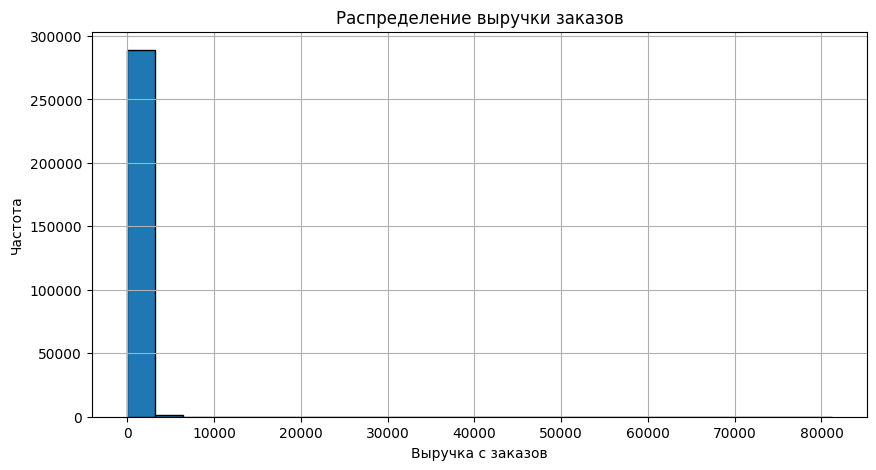

In [21]:
plt.figure(figsize=(10, 5))

df['revenue_rub'].plot(
    kind='hist',
    bins=25,
    edgecolor='black',
    rot=0
)
plt.title('Распределение выручки заказов')
plt.xlabel('Выручка с заказов')
plt.ylabel('Частота')
plt.grid()

plt.show()

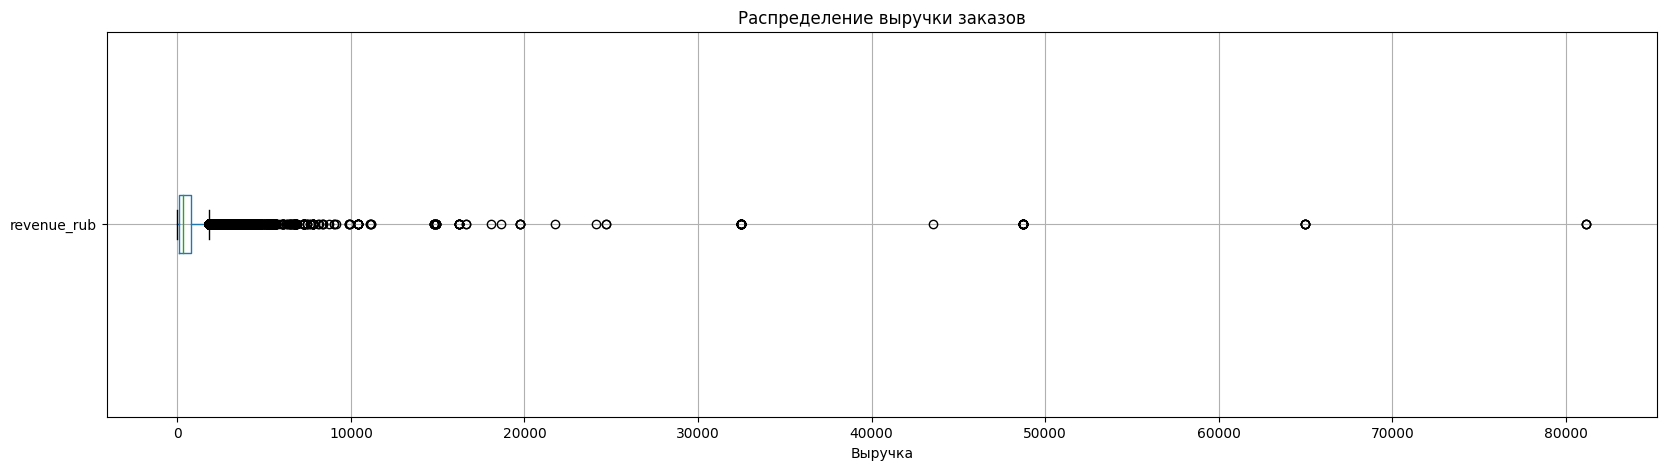

In [22]:
plt.figure(figsize=(20, 5))

df.boxplot(column='revenue_rub', vert=False)

plt.title('Распределение выручки заказов')
plt.xlabel('Выручка')
plt.show()

In [23]:
percentile_99 = df['revenue_rub'].quantile(0.99)

outliers_mask = df['revenue_rub'] > percentile_99

print(f"Значение 99-го перцентиля: {percentile_99:.2f}")
print(f"Количество выбросов: {outliers_mask.sum()}")
print(f"Процент выбросов: {outliers_mask.sum() / len(df) * 100:.2f}%")

df = df[df['revenue_rub'] <= percentile_99]

Значение 99-го перцентиля: 2610.32
Количество выбросов: 2870
Процент выбросов: 0.99%


In [24]:
# Статистические показатели

print('Статистические показатели столбца tickets_count:')
df['tickets_count'].describe()

Статистические показатели столбца tickets_count:


count    287360.000000
mean          2.740924
std           1.162700
min           1.000000
25%           2.000000
50%           3.000000
75%           3.000000
max          57.000000
Name: tickets_count, dtype: float64

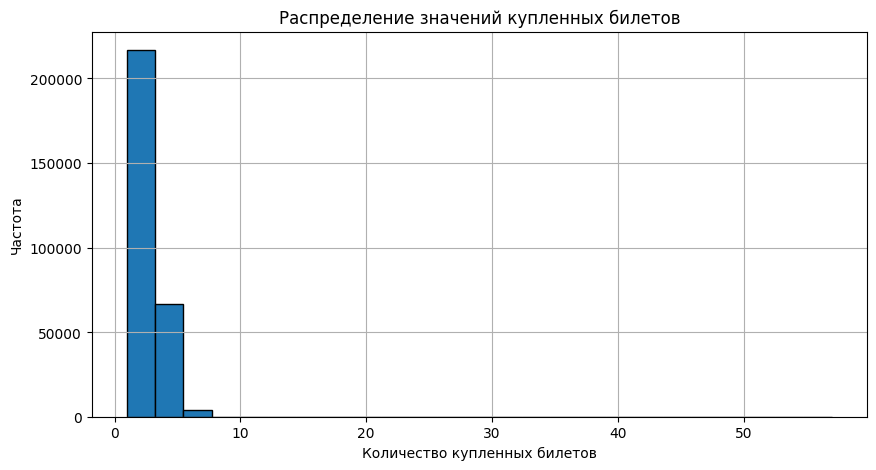

In [25]:
plt.figure(figsize=(10, 5))

df['tickets_count'].plot(
    kind='hist',
    bins=25,
    edgecolor='black',
    rot=0
)
plt.title('Распределение значений купленных билетов')
plt.xlabel('Количество купленных билетов')
plt.ylabel('Частота')
plt.grid()

plt.show()

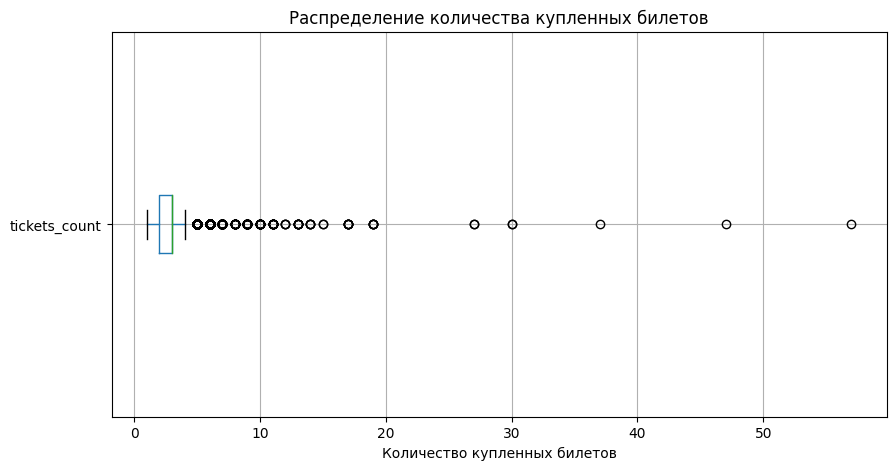

In [26]:
plt.figure(figsize=(10, 5))

df.boxplot(column='tickets_count', vert=False)

plt.title('Распределение количества купленных билетов')
plt.xlabel('Количество купленных билетов')
plt.show()

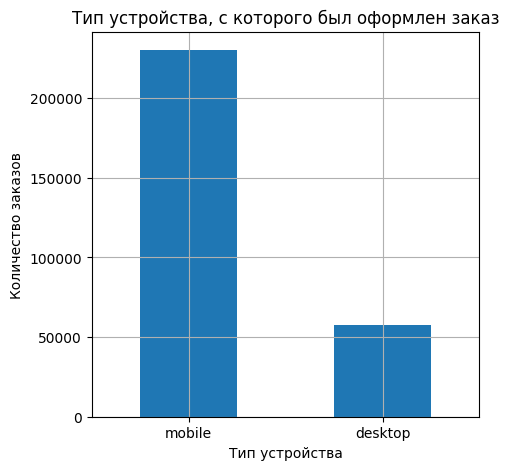

In [27]:
# Категории в столбце device_type_canonical
plt.figure(figsize = (5, 5))

df['device_type_canonical'].value_counts().plot(
    kind='bar',
    rot=0,
    title='Тип устройства, с которого был оформлен заказ',
    legend=False
)
plt.xlabel('Тип устройства')
plt.ylabel('Количество заказов')
plt.grid()
plt.show()

In [28]:
count_device_type_canonical = df['device_type_canonical'].value_counts()
percentages_device_type_canonical = df['device_type_canonical'].value_counts(normalize=True)
print('Количество устройств:')
print(count_device_type_canonical)
print('\nРаспределение заказов по категориям (%):')
print(percentages_device_type_canonical)

Количество устройств:
mobile     230070
desktop     57290
Name: device_type_canonical, dtype: int64

Распределение заказов по категориям (%):
mobile     0.800633
desktop    0.199367
Name: device_type_canonical, dtype: float64


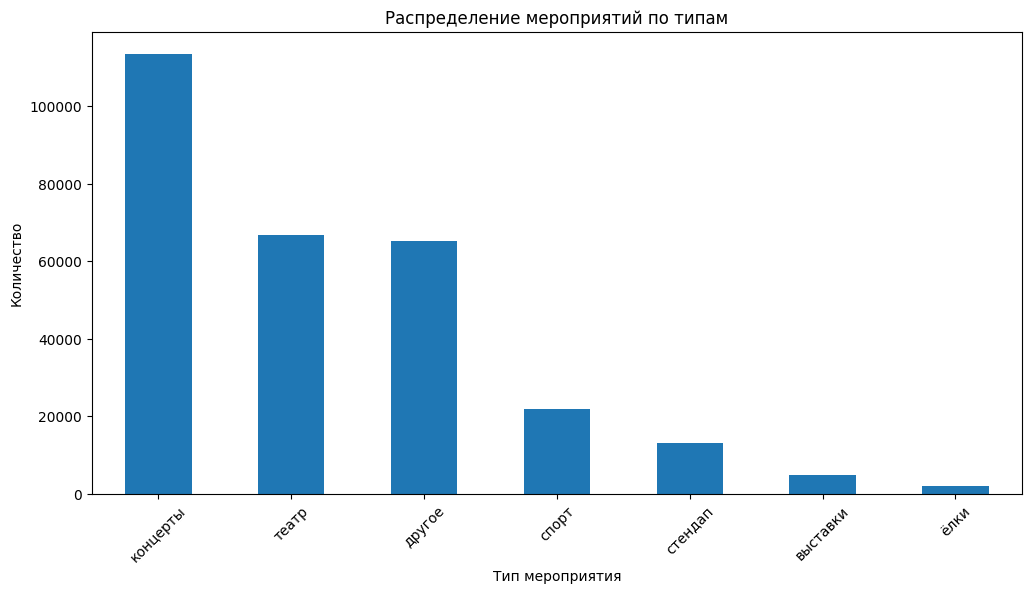

In [29]:
plt.figure(figsize=(12, 6))
df['event_type_main'].value_counts().plot(
    kind='bar',
    title='Распределение мероприятий по типам',
    rot=45
)
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество')
plt.show()

In [30]:
count_event_type_main = df['event_type_main'].value_counts()
percentages_event_type_main = df['event_type_main'].value_counts(normalize=True)
print('Количество мероприятий:')
print(count_event_type_main)
print('\nРаспределение мероприятий по категориям (%):')
print(percentages_event_type_main)

Количество мероприятий:
концерты    113436
театр        66713
другое       65291
спорт        21870
стендап      13272
выставки      4810
ёлки          1968
Name: event_type_main, dtype: int64

Распределение мероприятий по категориям (%):
концерты    0.394752
театр       0.232158
другое      0.227210
спорт       0.076107
стендап     0.046186
выставки    0.016739
ёлки        0.006849
Name: event_type_main, dtype: float64


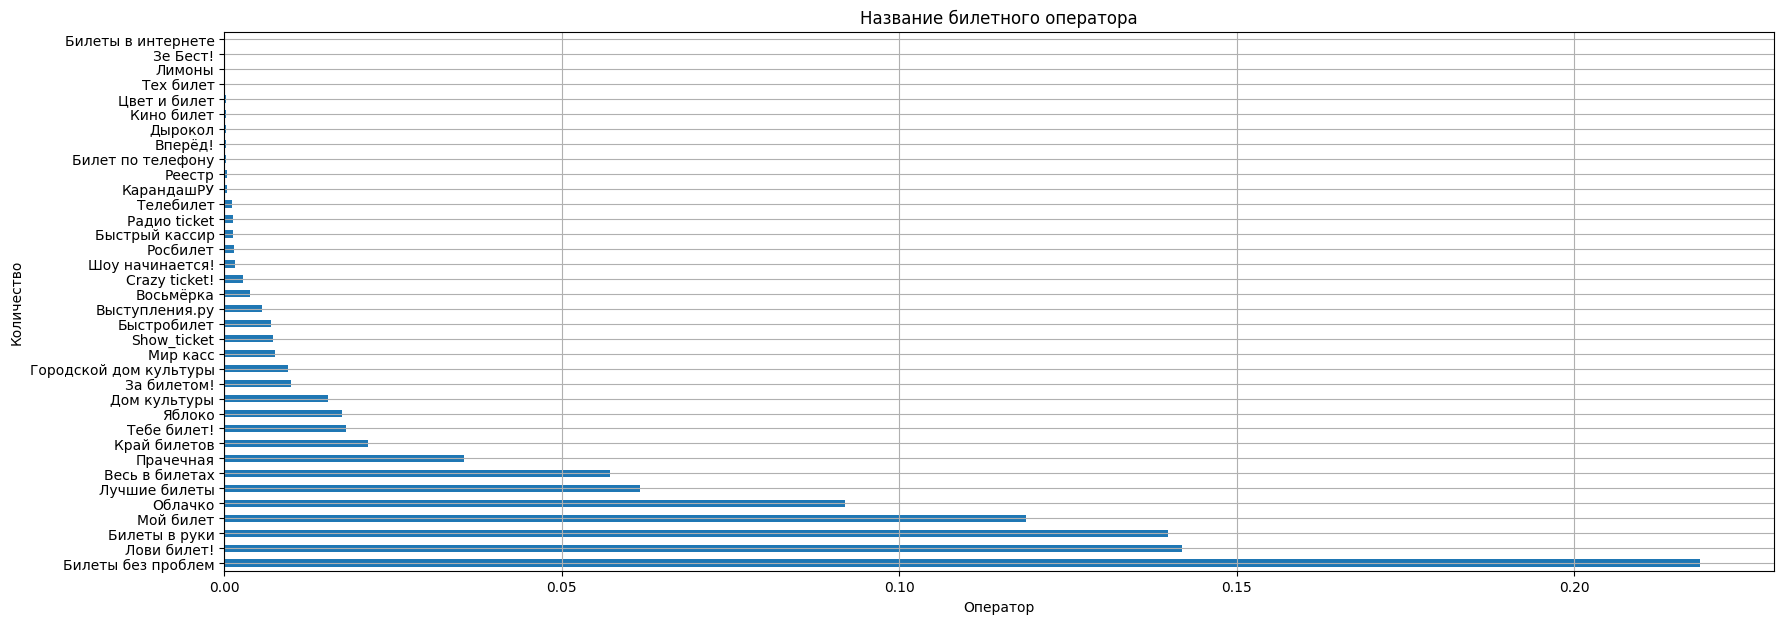

In [31]:
district_counts = df['service_name'].value_counts(normalize=True).sort_values(ascending=False)

plt.figure(figsize=(20, 7))

district_counts.plot(kind='barh')

plt.title('Название билетного оператора')
plt.xlabel('Оператор')
plt.ylabel('Количество')
plt.grid()

plt.show()

In [32]:
print('Количество билетных операторов')
print(district_counts)

Количество билетных операторов
Билеты без проблем        0.218705
Лови билет!               0.141947
Билеты в руки             0.139870
Мой билет                 0.118795
Облачко                   0.091906
Лучшие билеты             0.061654
Весь в билетах            0.057193
Прачечная                 0.035572
Край билетов              0.021266
Тебе билет!               0.018078
Яблоко                    0.017417
Дом культуры              0.015364
За билетом!               0.009935
Городской дом культуры    0.009490
Мир касс                  0.007458
Show_ticket               0.007273
Быстробилет               0.006901
Выступления.ру            0.005533
Восьмёрка                 0.003849
Crazy ticket!             0.002746
Шоу начинается!           0.001601
Росбилет                  0.001413
Быстрый кассир            0.001319
Радио ticket              0.001308
Телебилет                 0.001117
КарандашРУ                0.000463
Реестр                    0.000435
Билет по телефону       

In [33]:
# Полные дубликаты
duplicates_count = df.duplicated().sum()
print(f'Количество полных дубликатов: {duplicates_count}')
print(f'Процент дубликатов: {duplicates_count/len(df)*100:.2f}%')

Количество полных дубликатов: 0
Процент дубликатов: 0.00%


In [34]:
df = df.copy()
df['device_type_canonical'] = df['device_type_canonical'].str.lower().str.strip()
df['event_name'] = df['event_name'].str.lower().str.strip()
df['event_type_main'] = df['event_type_main'].str.lower().str.strip()
df['service_name'] = df['service_name'].str.lower().str.strip()
df['region_name'] = df['region_name'].str.lower().str.strip()
df['city_name'] = df['city_name'].str.lower().str.strip()

In [35]:
# Полные дубликаты
full_dupes = df[df.duplicated(keep=False)].sort_values(df.columns.tolist())
print(f"Полных дубликатов строк: {df.duplicated().sum()}")
print(f"Всего строк с дубликатами: {len(full_dupes)}")
print(f"Уникальных комбинаций среди дубликатов: {full_dupes.nunique()}")
full_dupes.head(20)

Полных дубликатов строк: 0
Всего строк с дубликатами: 0
Уникальных комбинаций среди дубликатов: user_id                  0
device_type_canonical    0
order_id                 0
order_dt                 0
order_ts                 0
currency_code            0
revenue                  0
tickets_count            0
days_since_prev          0
event_id                 0
event_name               0
event_type_main          0
service_name             0
region_name              0
city_name                0
revenue_rub              0
dtype: int64


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub


In [36]:
duplicates = df[df.duplicated(subset=['user_id', 'event_id', 'order_dt'], keep=False)]

# Создаем таблицу для просмотра с нужными колонками
display_table = duplicates[['user_id', 'event_id', 'order_dt', 'tickets_count', 'revenue_rub', 'event_type_main', 'service_name', 'region_name', 'order_ts']].head(20).copy()

# Сортируем для удобства просмотра
display_table = display_table.sort_values(['user_id', 'event_id', 'order_dt']).reset_index(drop=True)
display_table.index = range(1, len(display_table) + 1)

print(f"\nНайдено неполных дубликатов: {len(duplicates)}")
print(display_table.to_string())


Найдено неполных дубликатов: 142642
            user_id  event_id    order_dt  tickets_count  revenue_rub event_type_main        service_name          region_name            order_ts
1   000cf0659a9f40f    516728  2024-06-20              4      1421.91        концерты         лови билет!  широковская область 2024-06-20 10:35:26
2   000cf0659a9f40f    516728  2024-06-20              4      1421.91        концерты         лови билет!  широковская область 2024-06-20 12:40:27
3   000cf0659a9f40f    516728  2024-06-20              4      1421.91        концерты         лови билет!  широковская область 2024-06-20 12:42:12
4   000cf0659a9f40f    516728  2024-06-20              2       710.95        концерты         лови билет!  широковская область 2024-06-20 12:46:11
5   000cf0659a9f40f    516728  2024-06-20              3      1066.43        концерты         лови билет!  широковская область 2024-06-20 12:47:22
6   000cf0659a9f40f    516728  2024-06-20              4      1421.91        конц

В вывод попало 142642 строки, это очень большой объем данных, практически половина датафрейма, по столбцу order_ts видно, что дата и время в каждой строке отличается на несколько секунд, поэтому при отличии времени даже на нескольо секунду, мы не можем считать записи дубликатами, может быть пользователь покупал билет на разные группы лиц и технически это реализовать, как два раза нажать на кнопку покупки.

In [37]:
rows_after = df.shape[0]
cols_after = df.shape[1]

In [38]:
rows_deleted = rows_before - rows_after
deleted_percent = (rows_deleted / rows_before) * 100

print(f"Было записей: {rows_before}")
print(f"Стало записей: {rows_after}")
print(f"Удалено записей: {rows_deleted} ({deleted_percent:.2f})")

Было записей: 290611
Стало записей: 287360
Удалено записей: 3251 (1.12)


In [39]:
df.describe()

,order_id,revenue,tickets_count,days_since_prev,event_id,revenue_rub
count,2.873600e+05,287360.000000,287360.000000,265673.000000,287360.000000,287360.000000
mean,4.327025e+06,572.760193,2.740924,3.225345,437752.882378,518.505158
std,2.497638e+06,835.224304,1.162700,11.358011,147541.047370,511.372046
min,1.000000e+00,0.000000,1.000000,0.000000,4436.000000,0.000000
25%,2.165250e+06,116.239998,2.000000,0.000000,360736.500000,112.650000
50%,4.326874e+06,349.089996,3.000000,0.000000,496940.000000,345.010000
75%,6.489396e+06,795.780029,3.000000,1.000000,546268.000000,788.660000
max,8.653108e+06,13212.929688,57.000000,148.000000,592325.000000,2610.322394


**Промежуточный вывод:**
* Пропуски хранятся в столбце `days_since_prev`(количество дней с предыдущего заказа пользователя) - 21933 (0.0755%). Значения NULL означают, что пользователь совершал только оду покупку, первую, то есть нет второго дня дня. Пропуски оставляетм, чтобы понимать, что у пользователя только один первый заказ.
* Столбец `order_dt` преобразовали в тип - data, когда добавляли новый столбец с курсом, в котором хранится только значения в рублях.
* Отрицательные значения `revenue_rub` удалены - 381 записей, 0.13% Выбросы в столбце также удалены, в них входят значения выше 99-го перцентиля (2610.32 руб.), 2870 записей, что составляет 0,99% от общего объема данных. Потери минимальны, поэтому они не окажут значительного влияния на анализ, при этом исключены экстремально высокие значения, способные исказить статистические показатели.
* Судя о статистическим показателям столбца `tickets_count`, можно заметить, что максимальное количество купленных билетов составляет - 57 штук, это довольно большое значение, которое может говорить о лояльности и заинтересованности пользователя, при этом минимальное количество - 1 билет. Каждый клиент хотябы один раз приобретал билет на мероприятие. Разница между максимальным и минимальным количеством билетов большая - 56 штуки. Оставили данные, так как такое количество билетов мог купить клиент. После фильтрацию по 99 процентилю столбца `tickets_count` удалено 2870 (0.99%) записи.
* Преобразованы типы данных в некоторых столбцах с числовыми данными, размерность которых сократили.
* В столбце `device_type_canonical` хранятся данные, в которых хранится тип устройства, с которого оформлен заказ, по графику видно, что с мобильных устройст пользователи чаще делают заказы на 0.6%.
* Самым популярным мероприятием являются концерты (113436), наименее популярное мероприятие - ёлки (1968). Елки проводят толлько в определенный сезон, в основном в декабре, поэтому колличество мероприятий намного меньше, чем концертов, так как у них нет сезонности.
* Билетных операторов очень большое количество, самым популярный -  "Билеты без проблем" (0.219197%)
* Дубликатов не нашлось ни явных, ни неявных
* После предобрадотки данных удалено 3251 (1.12)

---

### 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас необходимо построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

---

In [40]:
df = df.sort_values(['user_id', 'order_dt']).reset_index(drop=True)

user_profile = df.groupby('user_id').agg(
    first_order_date=('order_dt', 'first'),
    last_order_date=('order_dt', 'last'),
    total_orders=('order_id', 'nunique'),
    avg_revenue=('revenue_rub', 'mean'),
    avg_tickets=('tickets_count', 'mean')
).reset_index()

In [41]:
first_orders = df.groupby('user_id').first().reset_index()
user_profile = user_profile.merge(
    first_orders[['user_id', 'device_type_canonical', 'region_name', 'service_name', 'event_type_main']],
    on='user_id', how='left'
).rename(columns={
    'device_type_canonical': 'first_device',
    'region_name': 'first_region',
    'service_name': 'first_partner',
    'event_type_main': 'first_genre'
})

In [42]:
last_orders = df.groupby('user_id').last().reset_index()
user_profile = user_profile.merge(
    last_orders[['user_id', 'days_since_prev']],
    on='user_id', how='left'
)

In [43]:
user_profile['is_two'] = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

In [44]:
user_profile = user_profile[[
    'user_id', 'first_order_date', 'last_order_date',
    'first_device', 'first_region', 'first_partner', 'first_genre',
    'total_orders', 'avg_revenue', 'avg_tickets', 'days_since_prev',
    'is_two', 'is_five'
]]

user_profile.head(10)

,user_id,first_order_date,last_order_date,first_device,first_region,first_partner,first_genre,total_orders,avg_revenue,avg_tickets,days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213333,2.666667,19.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0
5,000cf0659a9f40f,2024-06-20,2024-06-21,mobile,широковская область,лови билет!,концерты,13,1175.808462,3.307692,0.0,1,1
6,00147c9209d45d3,2024-06-25,2024-06-25,mobile,каменевский регион,облачко,концерты,2,352.945000,1.500000,0.0,1,0
7,0018ecd8a38a51b,2024-07-25,2024-07-25,mobile,медовская область,билеты без проблем,спорт,1,0.000000,3.000000,NaN,0,0
8,00199a573901564,2024-06-17,2024-06-17,mobile,каменевский регион,билеты без проблем,концерты,1,588.120000,4.000000,NaN,0,0
9,001e7037d013f0f,2024-07-04,2024-09-29,mobile,златопольский округ,мой билет,другое,3,326.623333,1.333333,13.0,1,0


In [45]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21834 entries, 0 to 21833
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           21834 non-null  object 
 1   first_order_date  21834 non-null  object 
 2   last_order_date   21834 non-null  object 
 3   first_device      21834 non-null  object 
 4   first_region      21834 non-null  object 
 5   first_partner     21834 non-null  object 
 6   first_genre       21834 non-null  object 
 7   total_orders      21834 non-null  int64  
 8   avg_revenue       21834 non-null  float64
 9   avg_tickets       21834 non-null  float64
 10  days_since_prev   13511 non-null  float64
 11  is_two            21834 non-null  int64  
 12  is_five           21834 non-null  int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 2.3+ MB


In [46]:
print(len(user_profile)),
print(user_profile['user_id'].nunique())
print(user_profile['is_two'].mean())
print(user_profile['is_five'].mean())

21834
21834
0.6170651277823578
0.2899606118897133


**Промежуточный вывод. Построение профиля пользователя:**
* Для каждого пользователя собраны метрики первого и последнего заказа
* Созданы новые столбцы: `is_two` (2 и более заказа), `is_five` (5 и более заказов)
* Профиль содержит 21850 строк, 21834 уникальных пользователей
* Доля повторных покупателей (2+): 61.7%
* Доля лояльных (5+): 29%



In [47]:
rows_before_user_profile = user_profile.shape[0]
cols_before_user_profile = user_profile.shape[1]

In [48]:
user_id_count = user_profile['user_id'].count()
print(user_id_count)

21834


In [49]:
avg_revenue_mean = user_profile['avg_revenue'].median()
print(avg_revenue_mean)

467.8382857142857


In [50]:
is_two_sum = user_profile['is_two'].sum()
percent_is_two = (is_two_sum / user_id_count) * 100
print(f'Доля пользователей с 2+ заказами: {percent_is_two:.1f}%')

Доля пользователей с 2+ заказами: 61.7%


In [51]:
is_five_sum = user_profile['is_five'].sum()
percent_is_five = (is_five_sum / user_id_count) * 100
print(f'Доля пользователей с 5+ заказами: {percent_is_five:.1f}%')

Доля пользователей с 5+ заказами: 29.0%


In [52]:
user_profile['total_orders'].describe()

count    21834.000000
mean        13.161125
std        121.567455
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max      10168.000000
Name: total_orders, dtype: float64

In [53]:
percentile_95_total_orders = user_profile['total_orders'].quantile(0.95)
percentile_99_total_orders = user_profile['total_orders'].quantile(0.99)
print(percentile_95_total_orders)
print(percentile_99_total_orders)

31.0
152.0


In [54]:
outliers_orders = user_profile[user_profile['total_orders'] > percentile_99_total_orders]
print(f'Пользователей с заказами > {percentile_99_total_orders:.0f}: {len(outliers_orders)} ({len(outliers_orders)/len(user_profile)*100:.2f}%)')
print(f"Максимум заказов: {user_profile['total_orders'].max()}")

Пользователей с заказами > 152: 216 (0.99%)
Максимум заказов: 10168


In [55]:
user_profile = user_profile[user_profile['total_orders'] < percentile_99_total_orders]
user_profile.head(10)

,user_id,first_order_date,last_order_date,first_device,first_region,first_partner,first_genre,total_orders,avg_revenue,avg_tickets,days_since_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,каменевский регион,край билетов,театр,1,1521.940000,4.000000,NaN,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,каменевский регион,мой билет,выставки,2,774.010000,3.000000,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,североярская область,лови билет!,другое,3,767.213333,2.666667,19.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,каменевский регион,край билетов,театр,1,917.830000,4.000000,NaN,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,поленовский край,лучшие билеты,театр,2,61.310000,1.500000,16.0,1,0
5,000cf0659a9f40f,2024-06-20,2024-06-21,mobile,широковская область,лови билет!,концерты,13,1175.808462,3.307692,0.0,1,1
6,00147c9209d45d3,2024-06-25,2024-06-25,mobile,каменевский регион,облачко,концерты,2,352.945000,1.500000,0.0,1,0
7,0018ecd8a38a51b,2024-07-25,2024-07-25,mobile,медовская область,билеты без проблем,спорт,1,0.000000,3.000000,NaN,0,0
8,00199a573901564,2024-06-17,2024-06-17,mobile,каменевский регион,билеты без проблем,концерты,1,588.120000,4.000000,NaN,0,0
9,001e7037d013f0f,2024-07-04,2024-09-29,mobile,златопольский округ,мой билет,другое,3,326.623333,1.333333,13.0,1,0


In [56]:
user_profile['avg_tickets'].describe()

count    21614.000000
mean         2.743439
std          0.916615
min          1.000000
25%          2.000000
50%          2.750000
75%          3.100000
max         11.000000
Name: avg_tickets, dtype: float64

In [57]:
# Преобразовываем столбцы first_order_date и last_order_date в datetime
user_profile['first_order_date'] = pd.to_datetime(user_profile['first_order_date'])
user_profile['last_order_date'] = pd.to_datetime(user_profile['last_order_date'])

In [58]:
days_between_stats = user_profile[user_profile['is_two'] == 1]['days_since_prev'].describe()
print("Статистика по среднему количеству дней между покупками (2+ заказов):")
print(days_between_stats)

Статистика по среднему количеству дней между покупками (2+ заказов):
count    13253.000000
mean        15.329737
std         26.923415
min          0.000000
25%          0.000000
50%          2.000000
75%         19.000000
max        148.000000
Name: days_since_prev, dtype: float64


In [59]:
rows_after_user_profile = user_profile.shape[0]
cols_after_user_profile = user_profile.shape[1]

In [60]:
rows_deleted_user_profile = rows_before_user_profile - rows_after_user_profile
deleted_percent_user_profile = (rows_deleted_user_profile / rows_before_user_profile) * 100

print(f"Было записей: {rows_before_user_profile}")
print(f"Стало записей: {rows_after_user_profile}")
print(f"Удалено записей: {rows_deleted_user_profile} ({deleted_percent_user_profile:.2f}%)")

Было записей: 21834
Стало записей: 21614
Удалено записей: 220 (1.01%)


In [61]:
user_profile.describe()

,total_orders,avg_revenue,avg_tickets,days_since_prev,is_two,is_five
count,21614.000000,21614.000000,21614.000000,13291.000000,21614.000000,21614.000000
mean,6.470251,545.153260,2.743439,15.366413,0.613167,0.282733
std,14.175337,432.690829,0.916615,26.986650,0.487036,0.450338
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,211.057500,2.000000,0.000000,0.000000,0.000000
50%,2.000000,464.853092,2.750000,2.000000,1.000000,0.000000
75%,5.000000,768.573333,3.100000,19.000000,1.000000,1.000000
max,151.000000,2610.322394,11.000000,148.000000,1.000000,1.000000


In [62]:
user_profile.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21614 entries, 0 to 21833
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           21614 non-null  object        
 1   first_order_date  21614 non-null  datetime64[ns]
 2   last_order_date   21614 non-null  datetime64[ns]
 3   first_device      21614 non-null  object        
 4   first_region      21614 non-null  object        
 5   first_partner     21614 non-null  object        
 6   first_genre       21614 non-null  object        
 7   total_orders      21614 non-null  int64         
 8   avg_revenue       21614 non-null  float64       
 9   avg_tickets       21614 non-null  float64       
 10  days_since_prev   13291 non-null  float64       
 11  is_two            21614 non-null  int64         
 12  is_five           21614 non-null  int64         
dtypes: datetime64[ns](2), float64(3), int64(3), object(5)
memory usage: 2.3+ MB


**Промежуточный вывод:**
* Общее число в выборке составляет 21834 пользователя. Этого достаточно для анализа данных. 61.7% совершили 2+ заказа и 29% 5+ заказов. Это показывает, что обычно клиенты совершают до 5 заказов.
* В столбце `total_orders` c общим количеством заказов наблюдаются аномалии - максимальное количество заказов составляет: 10168. Наблюдается аномалия в данных, поэтому произвели фильтрацию по 99 процентилю
* В столбце `avg_tickets` максимальное количество билетов в заказе - 11 штук. Это допустимо, например, один человек делал заказ на несколько человек, семьи или друзей.
* По статическим показателям по среднему количеству дней между покупками (2+ заказов), максимальное значение достигает 148 дней, такой резульат также допустим. Пользователь с большим перерывом делал заказ.
* После фильтрации в датафрейме стало 21614 заисей, удален 1.01% всех записей. В обновленном датасете `user_profile` 21614 строк, 13 колонок и занимает он 2.3+ MB.

---

### 4. Исследовательский анализ данных

Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используем профили пользователей.



#### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

Исследуем признаки, описывающие первый заказ пользователя, и выясняем, влияют ли они на вероятность возвращения пользователя.

---


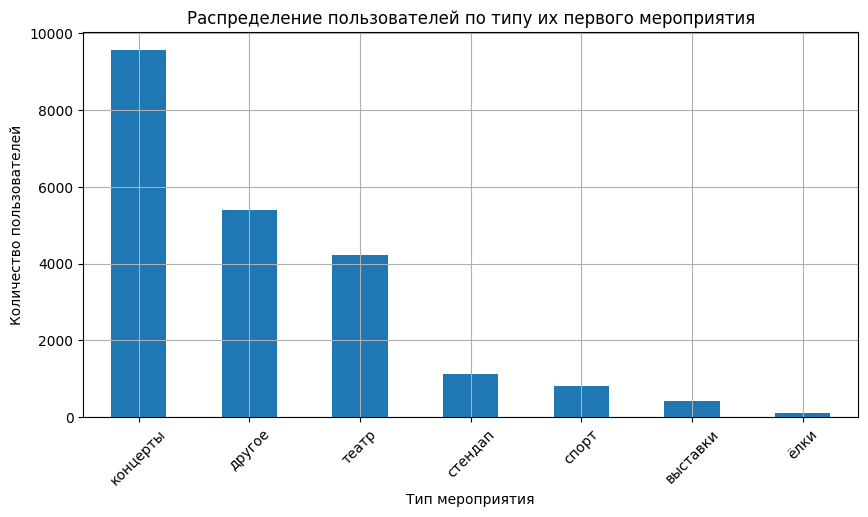

In [63]:
user_genre = user_profile['first_genre'].value_counts()
user_genre_percent = user_profile['first_genre'].value_counts(normalize=True)

plt.figure(figsize = (10, 5))

user_genre.plot(
    kind='bar',
    rot=45,
    title='Распределение пользователей по типу их первого мероприятия',
    legend=False
)
plt.xlabel('Тип мероприятия')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

In [64]:
print(f'Распределение пользователей по типу их первого мероприятия: \n{user_genre}\n')
print(f'Распределение пользователей по типу их первого мероприятия (%): \n{user_genre_percent}')

Распределение пользователей по типу их первого мероприятия: 
концерты    9559
другое      5408
театр       4228
стендап     1110
спорт        799
выставки     415
ёлки          95
Name: first_genre, dtype: int64

Распределение пользователей по типу их первого мероприятия (%): 
концерты    0.442260
другое      0.250208
театр       0.195614
стендап     0.051356
спорт       0.036967
выставки    0.019201
ёлки        0.004395
Name: first_genre, dtype: float64


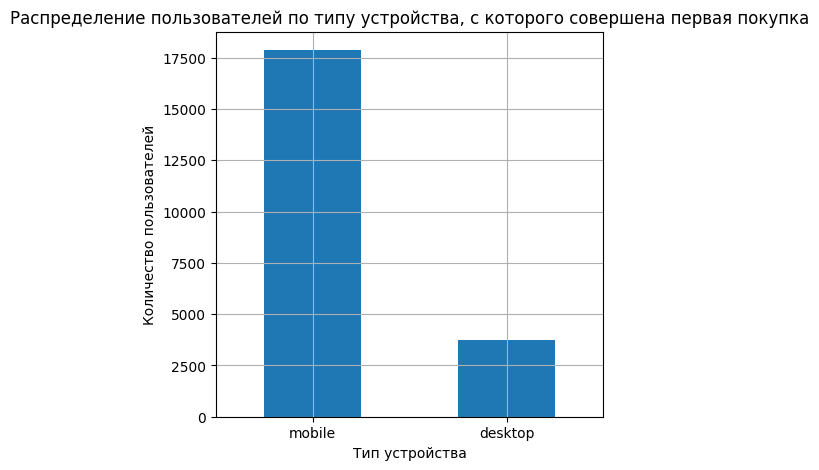

In [65]:
user_device = user_profile['first_device'].value_counts()
user_device_percent = user_profile['first_device'].value_counts(normalize=True)

plt.figure(figsize = (5, 5))

user_device.plot(
    kind='bar',
    rot=0,
    title='Распределение пользователей по типу устройства, с которого совершена первая покупка',
    legend=False
)
plt.xlabel('Тип устройства')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

In [66]:
print(f'Распределение пользователей по типу устройства, с которого совершена первая покупка: \n{user_device}\n')
print(f'Распределение пользователей по типу устройства, с которого совершена первая покупка (%): \n{user_device_percent}')

Распределение пользователей по типу устройства, с которого совершена первая покупка: 
mobile     17878
desktop     3736
Name: first_device, dtype: int64

Распределение пользователей по типу устройства, с которого совершена первая покупка (%): 
mobile     0.827149
desktop    0.172851
Name: first_device, dtype: float64


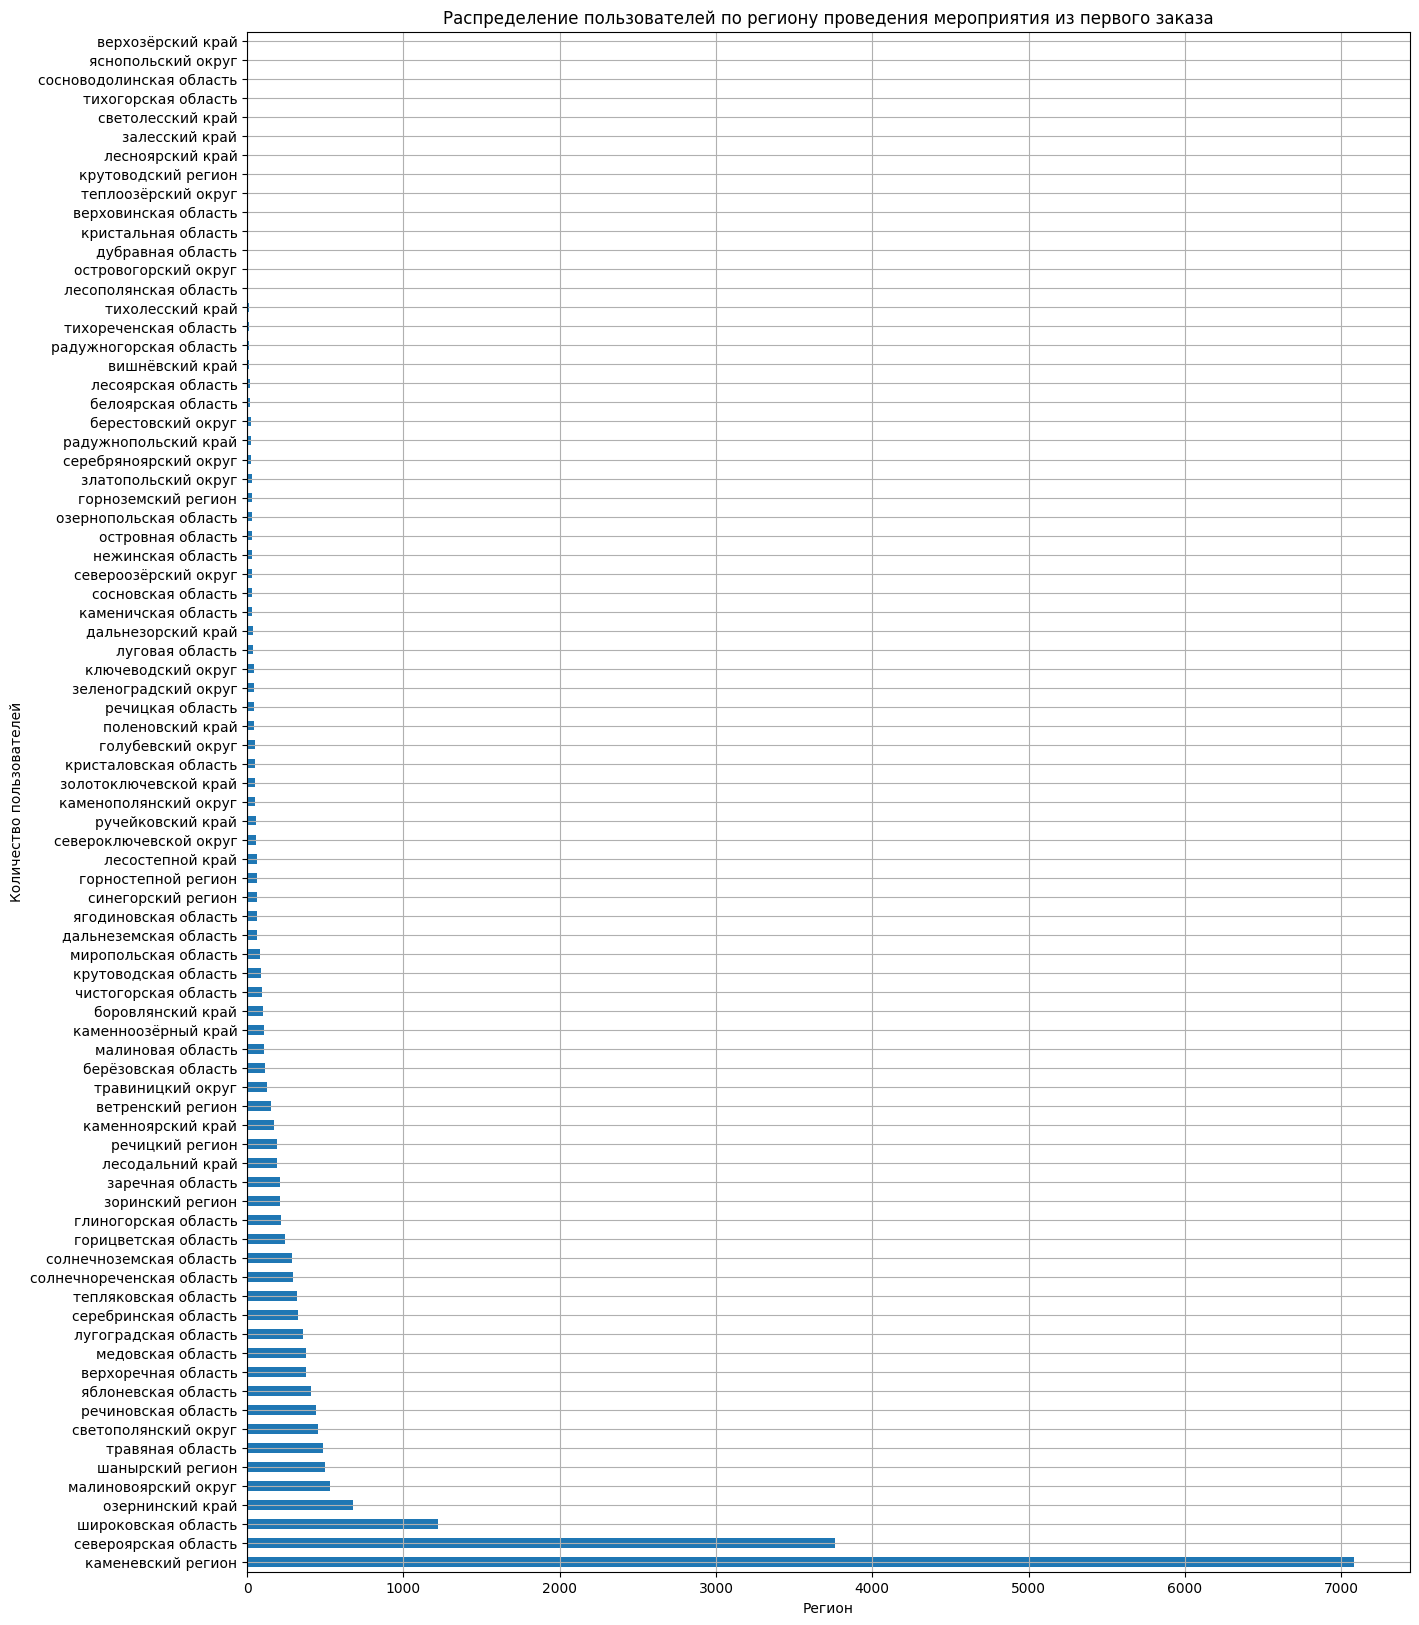

In [67]:
user_region = user_profile['first_region'].value_counts()
user_region_percent = user_profile['first_region'].value_counts(normalize=True)

plt.figure(figsize = (15, 20))

user_region.plot(kind='barh')
plt.title('Распределение пользователей по региону проведения мероприятия из первого заказа')
plt.xlabel('Регион')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

In [68]:
print(f'Распределение пользователей по билетному оператору, продавшему билеты на первый заказ: \n{user_region}\n')
print(f'Распределение пользователей по билетному оператору, продавшему билеты на первый заказ (%): \n{user_region_percent}')

Распределение пользователей по билетному оператору, продавшему билеты на первый заказ: 
каменевский регион          7084
североярская область        3764
широковская область         1221
озернинский край             677
малиновоярский округ         527
                            ... 
светолесский край              2
тихогорская область            2
сосноводолинская область       1
яснопольский округ             1
верхозёрский край              1
Name: first_region, Length: 81, dtype: int64

Распределение пользователей по билетному оператору, продавшему билеты на первый заказ (%): 
каменевский регион          0.327751
североярская область        0.174146
широковская область         0.056491
озернинский край            0.031322
малиновоярский округ        0.024382
                              ...   
светолесский край           0.000093
тихогорская область         0.000093
сосноводолинская область    0.000046
яснопольский округ          0.000046
верхозёрский край           0.000046
Name

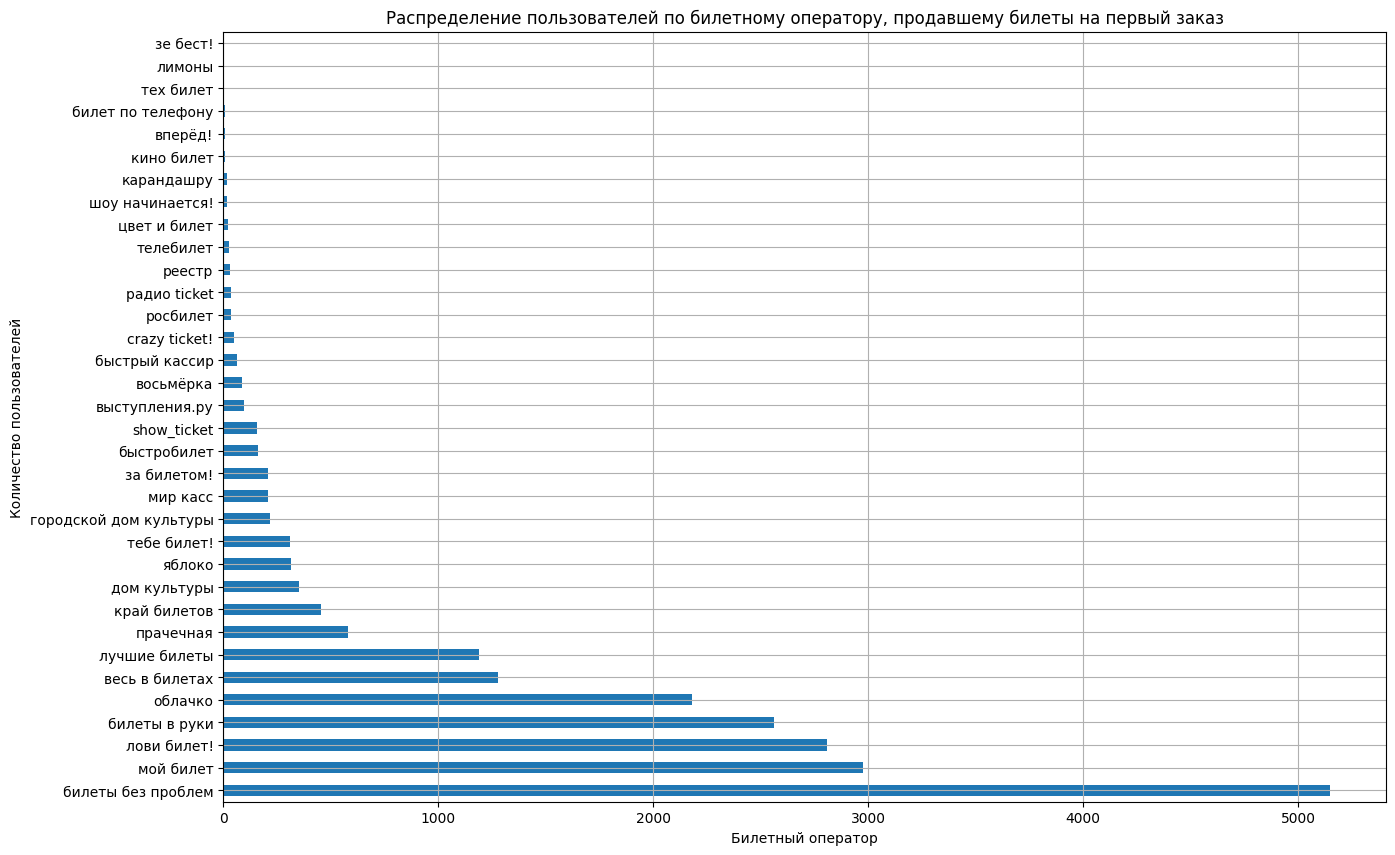

In [69]:
user_partner = user_profile['first_partner'].value_counts()
user_partner_percent = user_profile['first_partner'].value_counts(normalize=True)

plt.figure(figsize = (15, 10))

user_partner.plot(kind='barh')
plt.title('Распределение пользователей по билетному оператору, продавшему билеты на первый заказ')
plt.xlabel('Билетный оператор')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

In [70]:
print(f'Распределение пользователей по билетному оператору, продавшему билеты на первый заказ: \n{user_partner}\n')
print(f'Распределение пользователей по билетному оператору, продавшему билеты на первый заказ (%): \n{user_partner_percent}')

Распределение пользователей по билетному оператору, продавшему билеты на первый заказ: 
билеты без проблем        5151
мой билет                 2975
лови билет!               2808
билеты в руки             2561
облачко                   2179
весь в билетах            1279
лучшие билеты             1189
прачечная                  580
край билетов               454
дом культуры               352
яблоко                     317
тебе билет!                309
городской дом культуры     216
мир касс                   207
за билетом!                206
быстробилет                161
show_ticket                159
выступления.ру              97
восьмёрка                   85
быстрый кассир              62
crazy ticket!               48
росбилет                    38
радио ticket                36
реестр                      32
телебилет                   27
цвет и билет                23
шоу начинается!             19
карандашру                  15
кино билет                   9
вперёд!      

**Промежуточный вывод:**


По всем сегментам есть явные точки входа, которые привлекают большую долю клиентов, чем остальные. Наиболее популярное мероприятие - концерты 44.2%, они привлекают почти половину новых клиентов. Театр и другое значительно меньше, елки вообще охватывают только 0.4%, это показывает, что данный тип не столь популярный для новых пользователей и сезонный. Клиенты практически всегда приобретают билеты с мобильных устройств (83%) и в Каменевском регионе (32.7%), самый популярный билетный оператор "билеты без проблем", топ 5 операторов равно 64.5% и очень длинный хвост виден на графике - операторы с долей меньше 0.1%.

---

**4.1.2.** Анализируем возвраты пользователей.

---


In [71]:
avg_return = user_profile['is_two'].mean()
print(f'Среедняя доля по выборке 2+ заказов: {avg_return:.3f}')

Среедняя доля по выборке 2+ заказов: 0.613


In [72]:
genre_return = user_profile.groupby('first_genre')['is_two'].mean()
genre_return = genre_return.sort_values(ascending=False)
print(f'Средняя возвращаемость по выборке: {genre_return}')

Средняя возвращаемость по выборке: first_genre
выставки    0.643373
театр       0.632923
концерты    0.618161
стендап     0.609009
другое      0.596154
спорт       0.560701
ёлки        0.557895
Name: is_two, dtype: float64


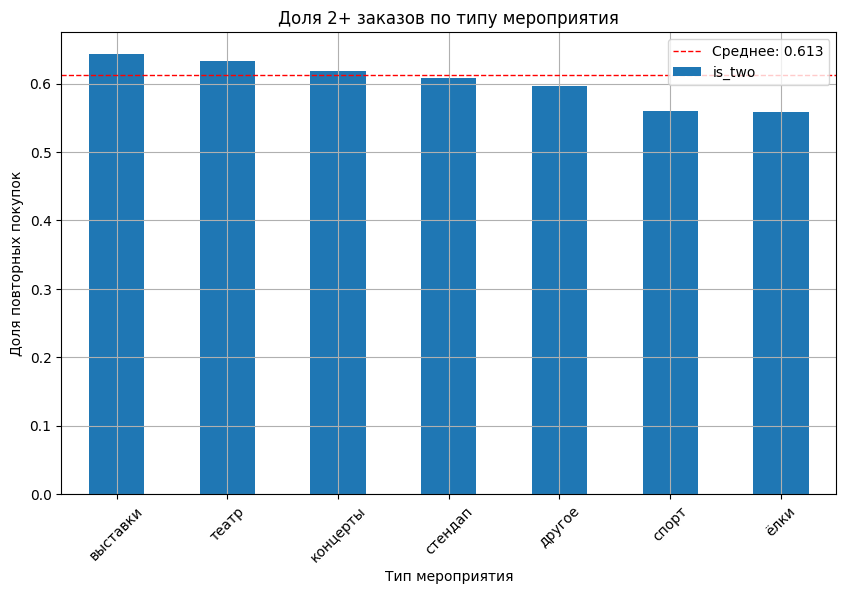

In [73]:
plt.figure(figsize=(10, 6))

genre_return.plot(
    kind='bar',
    title='Доля 2+ заказов по типу мероприятия',
    legend=True,
    xlabel='Тип мероприятия',
    ylabel='Доля повторных покупок',
    rot=45,
)

plt.axhline(
    avg_return,
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Среднее: {avg_return:.3f}')
plt.legend()
plt.grid()
plt.show()

In [74]:
device_return = user_profile.groupby('first_device')['is_two'].mean()
device_return = device_return.sort_values(ascending=False)
print(f'Средняя возвращаемость по выборке: {device_return}')

Средняя возвращаемость по выборке: first_device
desktop    0.640525
mobile     0.607450
Name: is_two, dtype: float64


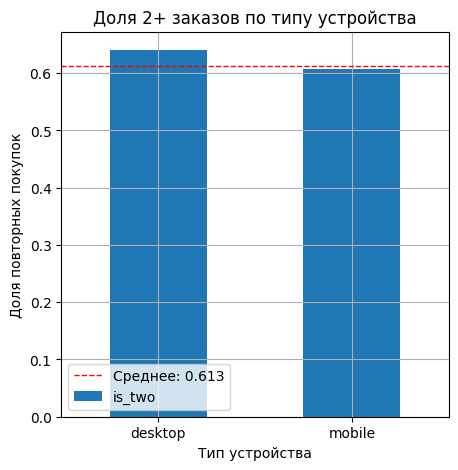

In [75]:
plt.figure(figsize=(5, 5))

device_return.plot(
    kind='bar',
    title='Доля 2+ заказов по типу устройства',
    legend=True,
    xlabel='Тип устройства',
    ylabel='Доля повторных покупок',
    rot=0,
)

plt.axhline(
    avg_return,
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Среднее: {avg_return:.3f}')
plt.legend()
plt.grid()
plt.show()

In [76]:
top10_regions = user_profile['first_region'].value_counts().head(10).index
region_return = user_profile[user_profile['first_region'].isin(top10_regions)].groupby('first_region')['is_two'].mean()
region_return = region_return.sort_values(ascending=False)
print(f'Средняя возвращаемость по выборке, топ-10 регион: {region_return}')

Средняя возвращаемость по выборке, топ-10 регион: first_region
шанырский регион        0.672000
светополянский округ    0.655702
широковская область     0.643735
североярская область    0.637885
речиновская область     0.632420
каменевский регион      0.624082
травяная область        0.613963
яблоневская область     0.593674
малиновоярский округ    0.559772
озернинский край        0.553914
Name: is_two, dtype: float64


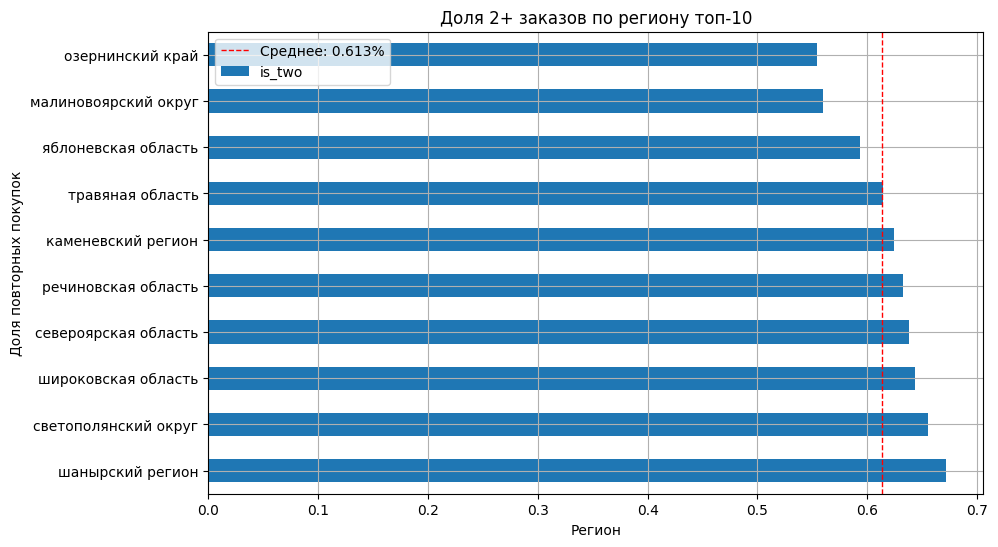

In [77]:
plt.figure(figsize=(10, 6))

region_return.plot(
    kind='barh',
    title='Доля 2+ заказов по региону топ-10',
    legend=True,
    xlabel='Регион',
    ylabel='Доля повторных покупок',
    rot=0,
)

plt.axvline(
    avg_return,
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Среднее: {avg_return:.3f}%')
plt.legend()
plt.grid()
plt.show()

In [78]:
top10_partners = user_profile['first_partner'].value_counts().head(10).index
partner_return = user_profile[user_profile['first_partner'].isin(top10_partners)].groupby('first_partner')['is_two'].mean()
partner_return = partner_return.sort_values(ascending=False)
print(f'Средняя возвращаемость по выборке, топ-10 оператор: {partner_return}')

Средняя возвращаемость по выборке, топ-10 оператор: first_partner
край билетов          0.649780
дом культуры          0.647727
билеты в руки         0.628270
весь в билетах        0.627052
прачечная             0.624138
лучшие билеты         0.615643
облачко               0.612666
мой билет             0.609412
лови билет!           0.608974
билеты без проблем    0.602019
Name: is_two, dtype: float64


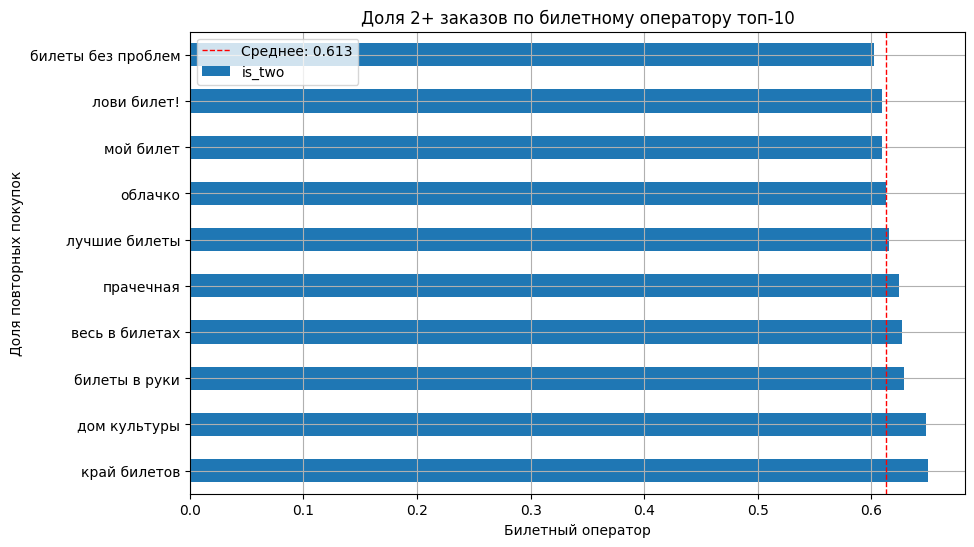

In [79]:
plt.figure(figsize=(10, 6))

partner_return.plot(
    kind='barh',
    title='Доля 2+ заказов по билетному оператору топ-10',
    legend=True,
    xlabel='Билетный оператор',
    ylabel='Доля повторных покупок',
    rot=0,
)

plt.axvline(
    avg_return,
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'Среднее: {avg_return:.3f}')
plt.legend()
plt.grid()
plt.show()

**Промежуточный вывод:**


Выявлены успешные точки входа, сегменты с высоким удержанием. Средняя доля пользователей с 2+ заказами составляет 61.3%. Процент больше половины, что говорит о том, что пользователи совершают не один заказ и возвращаются. Клиенты чаще возвращаются в Яндекс Афишу, если покупают билеты на выставку с декстопного устройства из шанырского региона через оператора "край билетов".
* Самым востребованным меропиятием, куда клиенты хотят ходить больше 1 раза - это выставки 64.2%. На елки возвращаются пользователи 55.8%, это снова указывает на то, что сезонный сегмент с малым размером и данные нестабильны. Но процентные данные больше половины.
* А вот покупают билеты повторный раз чаще всего с декстопных устройст, что не сказать о первом заказе, в которых было наоборот, декстобные устройства там уступали мобильным. Пользователи с компьютеров возвращаются чаще, хотя их меньше по количеству.
* В топ-10 регионов вошли места с разницей около 1-2%. Первый в списке стоит шанырский регион 67% (+5.8% к среднему), десятый - озернинский край (55.4%). Разница между ними составляет примерно 11.6%. Малиновоярский округ    56% и озернинский край 55.4%. Необходимо отметить, что крупнейший регион (каменевский) даёт средний возврат, а меньшие регионы показывают хорошие результаты.
* Небольшие операторы показывают лучшую лояльность клиентов, потому что успешные точки входа - край билетов (64.98%) и дом культуры (64.8%). Крупнейший оператор (билеты без проблем) имеет самую низкую возвращаемость в топ-10 (60.3%)


---

**4.1.3.** Проверка продуктовых гипотез:

- **Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.
- **Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

---

In [80]:
# 1 гипотеза
concert_return = genre_return['концерты']
sport_return = genre_return['спорт']
print(f"Концерты: {concert_return:.4f}")
print(f"Спорт: {sport_return:.4f}")
print(f"Среднее по выборке: {avg_return:.4f}")

Концерты: 0.6182
Спорт: 0.5607
Среднее по выборке: 0.6132


In [81]:
concert_size = (user_profile['first_genre'] == 'концерты').sum()
sport_size = (user_profile['first_genre'] == 'спорт').sum()

print(f'Концерты: {concert_return:.2f} - Размер выбори: {concert_size}')
print(f'Спорт: {sport_return:.2f} - Размер выбори: {sport_size}')

Концерты: 0.62 - Размер выбори: 9559
Спорт: 0.56 - Размер выбори: 799


In [82]:
diff = concert_return - sport_return
print(f'Разница между концертом и спортом: {diff}')

Разница между концертом и спортом: 0.057460019396041284


In [83]:
# 2 гипотеза
# все регионы с размером и возвратом
region_stats = user_profile.groupby('first_region').agg(
    size=('first_region', 'count'),
    return_rate=('is_two', 'mean')
)
region_stats['return_rate'] = region_stats['return_rate']
print(f'Всего регионов: {len(region_stats)}')

Всего регионов: 81


In [84]:
active_regions = region_stats.sort_values('size', ascending=False).head(10).copy()
active_avg_return = active_regions['return_rate'].mean()
print(f'Среднее по топ-10 активным регионам: {active_avg_return}')

Среднее по топ-10 активным регионам: 0.6187147786108556


In [85]:
small_regions = region_stats[region_stats['size'] < 100].copy()
small_avg_return = small_regions['return_rate'].mean() if len(small_regions) > 0 else None

In [86]:
avg_return = user_profile['is_two'].mean()
print(f'Среднее по выборке: {avg_return}')

Среднее по выборке: 0.6131673915055057


In [87]:
print(f'топ-5 активных регионов по размеру:')
for i, (region, row) in enumerate(active_regions.head(5).iterrows(), 1):
    status = 'выше' if row['return_rate'] > avg_return else 'ниже'
    print(f"{region}: {row['return_rate']} (n={int(row['size'])}) - {status} среднего")

топ-5 активных регионов по размеру:
каменевский регион: 0.6240824392998306 (n=7084) - выше среднего
североярская область: 0.63788522848034 (n=3764) - выше среднего
широковская область: 0.6437346437346437 (n=1221) - выше среднего
озернинский край: 0.5539143279172821 (n=677) - ниже среднего
малиновоярский округ: 0.5597722960151803 (n=527) - ниже среднего


In [88]:
# Сравниваем активные с неактивными
valid_small = small_regions[small_regions['size'] >= 30]
if len(valid_small) > 0:
    small_valid_avg = valid_small['return_rate'].mean()
    print(f"Среднее по активным (ТОП-10): {active_avg_return:.2f}%")
    print(f"Среднее по малым (n>=100):    {small_valid_avg:.2f}%")

    if active_avg_return > small_valid_avg:
        print(f'активные ({active_avg_return}) > малые ({small_valid_avg})')
    else:
        print(f'активные ({active_avg_return}) < малые ({small_valid_avg})')
else:
    print(f"недостаточно малых регионов с размером >=30")

Среднее по активным (ТОП-10): 0.62%
Среднее по малым (n>=100):    0.55%
активные (0.6187147786108556) > малые (0.5473898585455514)


**Промежуточный вывод:**


***1 гитореза не подтверждается***, так как концерты (62%) занимают выше место в списке по возращаемости клиентов в Яндекс Афишу, а спорт составляет 56%, клиенты, которые совершили первый заказ на спортивные мероприятия реже возвращаются на сервис. Концерты на 0.5% выше среднего.

***2 гитореза не подтверждается***, активные регионы не возвращаются чаще, так как среднее по выборке 61.3%. Всего регионов: 81. В топ-5 активных регионов по размеру входят:каменевский регион: 0.62 (7083), североярская область: 0.64 (3763), широковская область: 0.64 (1222) - выше среднего, а озернинский край: 0.55 (677), малиновоярский округ: 0.56 (526). Два из пяти ниже среднего. Среднее по топ-5 активным регионам: 60.4%. Ниже чем среднее по выборке.

---

#### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

Изучаем количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

---

**4.2.1.** Связь между средней выручкой сервиса с заказа и повторными заказами.

---


In [89]:
user_profile['is_one'] = (user_profile['total_orders'] == 1).astype(int)

In [90]:
one_order = user_profile[user_profile['is_one'] == 1]['avg_revenue']
two_plus_orders = user_profile[user_profile['is_two'] == 1]['avg_revenue']

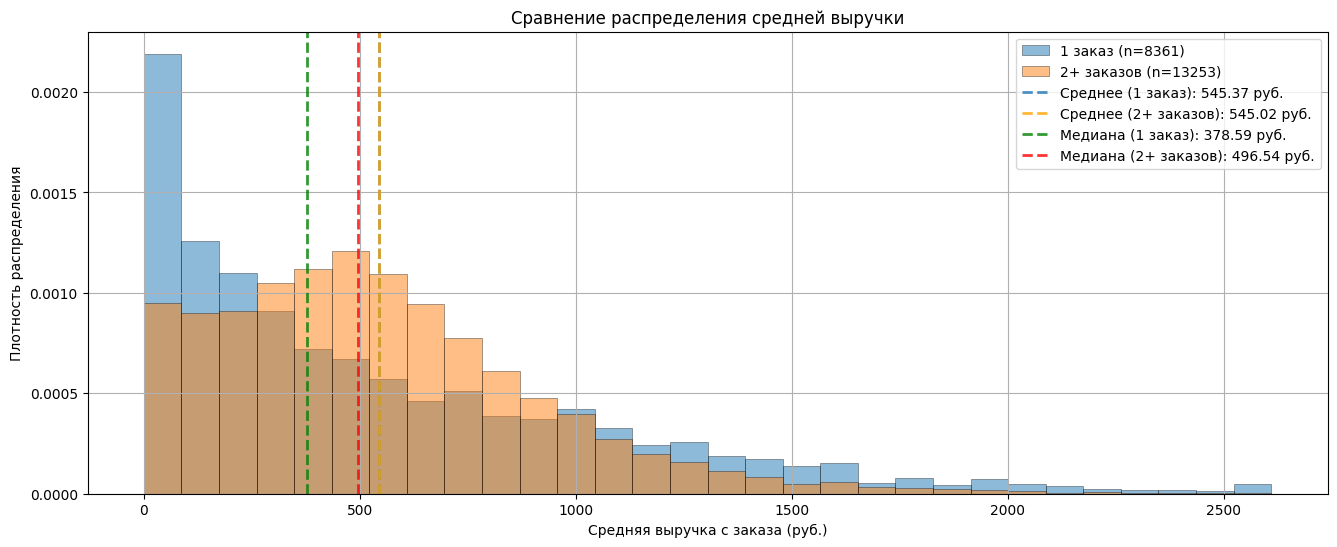

In [91]:
plt.figure(figsize=(16, 6))
# гистограмма для 1 заказа
one_order.plot.hist(
    bins=30,
    density=True,
    alpha=0.5,
    label=f'1 заказ (n={len(one_order)})',
    edgecolor='black',
    linewidth=0.5
)

# Гистограмма для 2+ заказов
two_plus_orders.plot.hist(
    bins=30,
    density=True,
    alpha=0.5,
    label=f'2+ заказов (n={len(two_plus_orders)})',
    edgecolor='black',
    linewidth=0.5
)

# Линии средних значений
plt.axvline(one_order.mean(), linestyle='--', alpha=0.8,
            linewidth=2, label=f'Среднее (1 заказ): {one_order.mean():.2f} руб.')
plt.axvline(two_plus_orders.mean(), color='orange', linestyle='--', alpha=0.8,
            linewidth=2, label=f'Среднее (2+ заказов): {two_plus_orders.mean():.2f} руб.')

# Медиана
plt.axvline(one_order.median(), color='green', linestyle='--', alpha=0.8,
            linewidth=2, label=f'Медиана (1 заказ): {one_order.median():.2f} руб.')
plt.axvline(two_plus_orders.median(), color='red', linestyle='--', alpha=0.8,
            linewidth=2, label=f'Медиана (2+ заказов): {two_plus_orders.median():.2f} руб.')

plt.xlabel('Средняя выручка с заказа (руб.)')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределения средней выручки')
plt.legend()
plt.grid()
plt.show()

In [92]:
print(f'Среднее (1 заказ): {one_order.mean():.2f}')
print(f'Среднее (2+ заказов): {two_plus_orders.mean():.2f}')
print(f'Медиана (1 заказ): {one_order.median():.2f}')
print(f'Медиана (2+ заказов): {two_plus_orders.median():.2f}')

Среднее (1 заказ): 545.37
Среднее (2+ заказов): 545.02
Медиана (1 заказ): 378.59
Медиана (2+ заказов): 496.54


**Промежуточный вывод:**


Группы отличаются чем, что у пользователей с 1 заказом виден большой скачок в диапазоне от 0 до примерно 84. Группа пользователей с 2+ заказами распределяется в начале более равномерно, но после значения 1000 виден явный спад и появляется правый хвост.

Пользователи из каждой группы концентрируются примерно в диапазонах от 400 до 700 рублей. Явных различий между группами не наблюдается, средние значения практически совпадают, разница составляет 0.61 руб. По диаграмме видно, что у графиков похожая форма, есть длинный хвост распределения 1500+ рублей. Средний чек не является фактором, влияющим на возвращаемость в данном наборе данных. Обе группы показывают одинаковое распределение средней выручки.

У группы с одним заказом среднее значение больше, чем медиана - смещение вправо, большинство пользователей делают небольшие заказы (вокруг 378 руб.). Разрыв между средним и медианой большой (166 руб.) — это указывает на наличие заметных выбросов, возможно, это очень дорогие заказы.

У группы с 2+ заказами умеренное смещение вправо, среднее больше медианы - пользователи с повторными заказами делают более стабильные по сумме покупки.

---

**4.2.2.** Сравниваем распределение по средней выручке с заказа в двух группах пользователей:

- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

---


In [93]:
orders_2_4 = user_profile[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0)]['avg_revenue']
orders_5plus = user_profile[user_profile['is_five'] == 1]['avg_revenue']

In [94]:
orders_2_4.describe()

count    7142.000000
mean      552.261722
std       419.579933
min         0.000000
25%       219.412500
50%       472.135000
75%       798.795625
max      2610.322394
Name: avg_revenue, dtype: float64

In [95]:
orders_5plus.describe()

count    6111.000000
mean      536.553017
std       298.792346
min         0.000000
25%       331.802208
50%       512.946000
75%       701.221446
max      2284.032094
Name: avg_revenue, dtype: float64

In [96]:
round((orders_2_4.mean() - orders_5plus.mean()), 2)

15.71

In [97]:
all_data = pd.concat([orders_2_4, orders_5plus])

step = 50

min_value = (all_data.min() // step) * step
max_value = (all_data.max() // step) * step + step

bins = np.arange(min_value, max_value + step, step)

print(f"Диапазон цен: от {min_value:.0f} до {max_value:.0f} руб.")
print(f"Количество бинов: {len(bins)-1}")
print(f"Шаг бина: {step} руб.")

Диапазон цен: от 0 до 2650 руб.
Количество бинов: 53
Шаг бина: 50 руб.


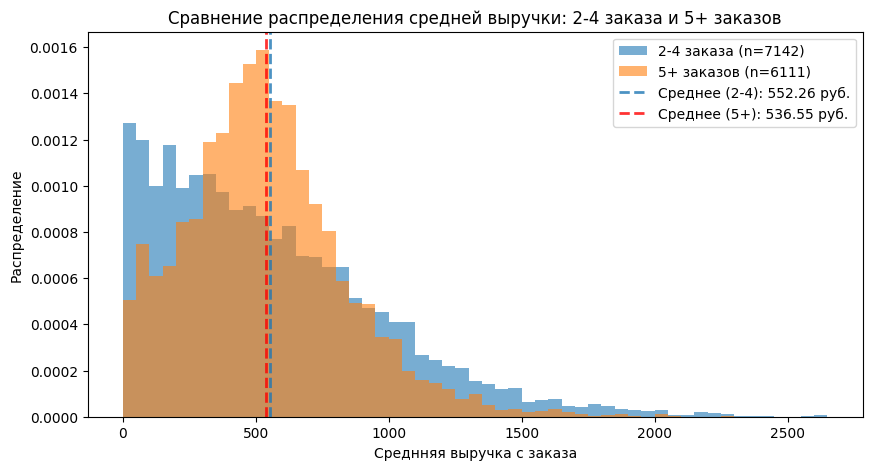

In [98]:
plt.figure(figsize=(10, 5))

orders_2_4.hist(bins=bins, density=True, alpha=0.6,
                label=f'2-4 заказа (n={len(orders_2_4)})')

orders_5plus.hist(bins=bins, density=True, alpha=0.6,
                label=f'5+ заказов (n={len(orders_5plus)})')


plt.axvline(orders_2_4.mean(), linestyle='--', alpha=0.8, linewidth=2, label=f'Среднее (2-4): {orders_2_4.mean():.2f} руб.')
plt.axvline(orders_5plus.mean(), linestyle='--', color='red', alpha=0.8, linewidth=2, label=f'Среднее (5+): {orders_5plus.mean():.2f} руб.')

plt.xlabel('Среднняя выручка с заказа')
plt.ylabel('Распределение')
plt.title('Сравнение распределения средней выручки: 2-4 заказа и 5+ заказов')
plt.legend()
plt.grid()
plt.show()

**Промежуточный вывод:**


Различий в средней выручке с заказов в двух группах пользователей практически нет, она составляет 15.68 рублей. Но при этом в группе с 5+ заказами наблюдается большой разброс данных, графики не похожи межды собой, график с 2-4 хаказами имеет правый хвост.

---

**4.2.3.** Анализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.

---

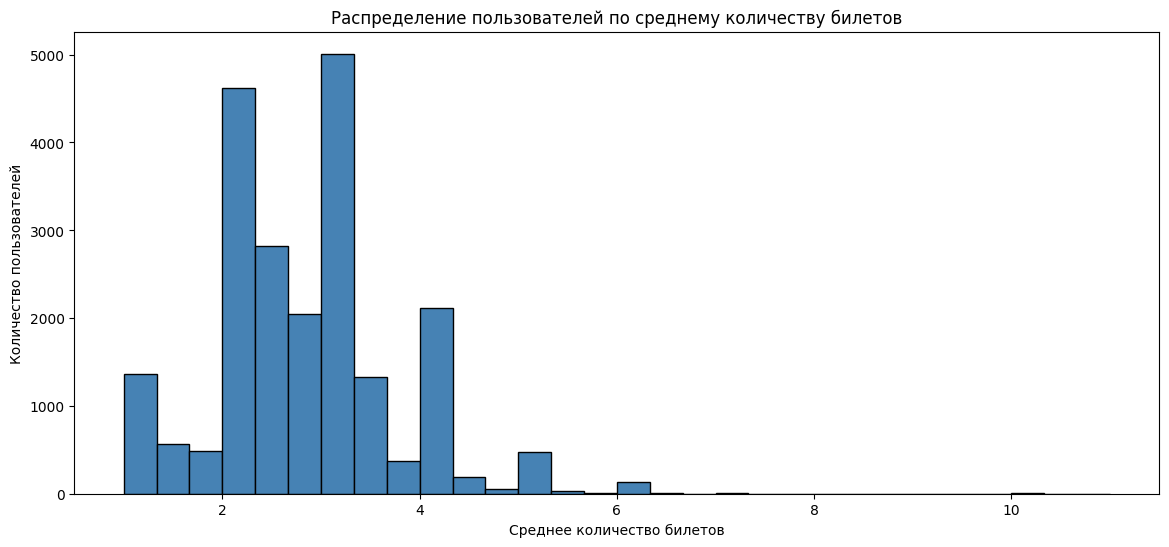

In [99]:
plt.figure(figsize=(14, 6))

user_profile['avg_tickets'].hist(bins=30, edgecolor='black', color='steelblue')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Количество пользователей')
plt.title('Распределение пользователей по среднему количеству билетов')
plt.grid()
plt.show()

In [100]:
tickets_1_2 = user_profile[(user_profile['avg_tickets'] >= 1) & (user_profile['avg_tickets'] < 2)]

tickets_1_2['avg_tickets'].describe()

count    2410.000000
mean        1.266430
std         0.316319
min         1.000000
25%         1.000000
50%         1.000000
75%         1.500000
max         1.971429
Name: avg_tickets, dtype: float64

In [101]:
size_1_2 = len(tickets_1_2)
percent_total_1_2 = (size_1_2 / len(user_profile))
return_rate_1_2 = tickets_1_2['is_two'].mean()
avg_revenue_1_2 = tickets_1_2['avg_revenue'].mean()

print(f'Количество пользователей: {size_1_2}')
print(f'Доля от всех пользователей: {percent_total_1_2}')
print(f'Доля повторных покупок: {return_rate_1_2}')
print(f'Средний чек: {avg_revenue_1_2}')

Количество пользователей: 2410
Доля от всех пользователей: 0.11150180438604608
Доля повторных покупок: 0.5124481327800829
Средний чек: 242.37650582459136


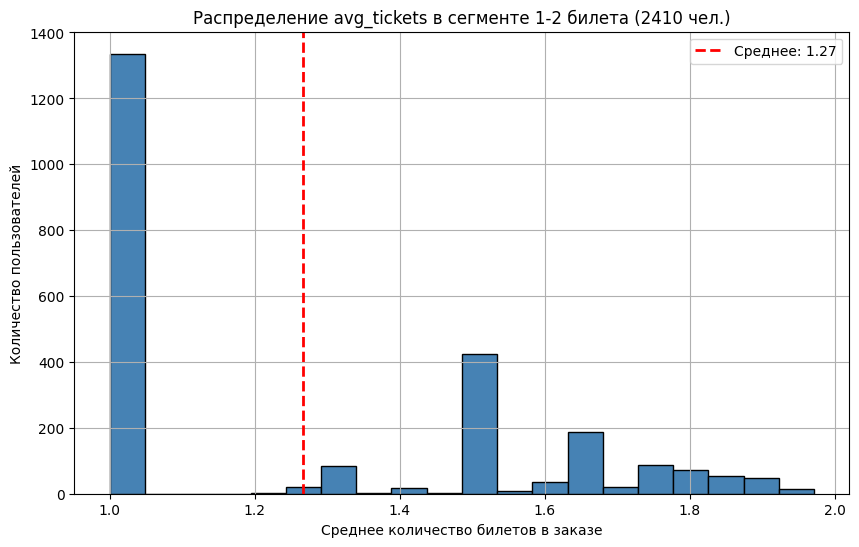

In [102]:
plt.figure(figsize=(10, 6))

plt.hist(tickets_1_2['avg_tickets'], bins=20,
         color='steelblue', edgecolor='black')

plt.axvline(tickets_1_2['avg_tickets'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Среднее: {tickets_1_2["avg_tickets"].mean():.2f}')

plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title(f'Распределение avg_tickets в сегменте 1-2 билета ({len(tickets_1_2)} чел.)')
plt.legend()
plt.grid()
plt.show()

In [103]:
tickets_2_3 = user_profile[(user_profile['avg_tickets'] >= 2) & (user_profile['avg_tickets'] < 3)]

tickets_2_3['avg_tickets'].describe()

count    9486.000000
mean        2.327253
std         0.311120
min         2.000000
25%         2.000000
50%         2.333333
75%         2.600000
max         2.985915
Name: avg_tickets, dtype: float64

In [104]:
size_2_3 = len(tickets_2_3)
percent_total_2_3 = (size_2_3 / len(user_profile))
return_rate_2_3 = tickets_2_3['is_two'].mean()
avg_revenue_2_3 = tickets_2_3['avg_revenue'].mean()

print(f'Количество пользователей: {size_2_3}')
print(f'Доля от всех пользователей: {percent_total_2_3}')
print(f'Доля повторных покупок: {return_rate_2_3}')
print(f'Средний чек: {avg_revenue_2_3}')

Количество пользователей: 9486
Доля от всех пользователей: 0.43888220597760713
Доля повторных покупок: 0.7355049546700401
Средний чек: 470.8462151906702


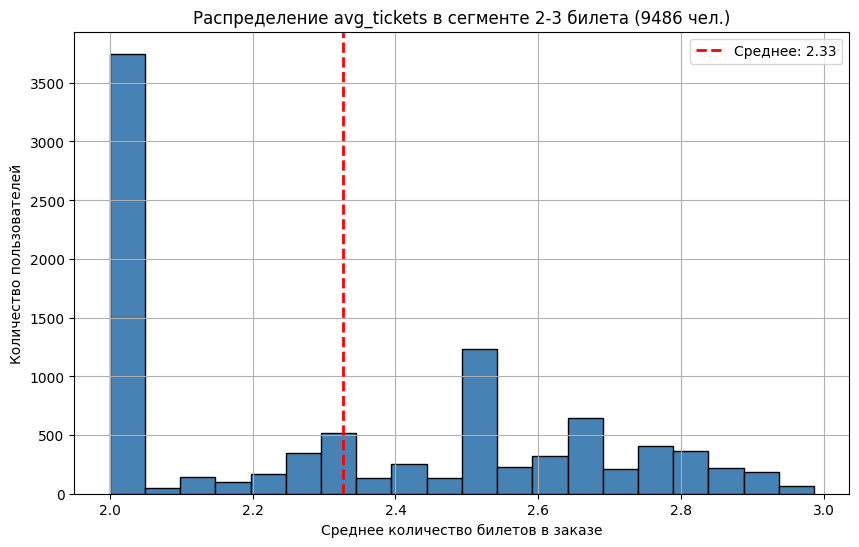

In [105]:
plt.figure(figsize=(10, 6))

plt.hist(tickets_2_3['avg_tickets'], bins=20,
         color='steelblue', edgecolor='black')

plt.axvline(tickets_2_3['avg_tickets'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Среднее: {tickets_2_3["avg_tickets"].mean():.2f}')

plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title(f'Распределение avg_tickets в сегменте 2-3 билета ({len(tickets_2_3)} чел.)')
plt.legend()
plt.grid()
plt.show()

In [106]:
tickets_3_5 = user_profile[(user_profile['avg_tickets'] >= 3) & (user_profile['avg_tickets'] < 5)]

tickets_3_5['avg_tickets'].describe()

count    9061.000000
mean        3.387275
std         0.451361
min         3.000000
25%         3.000000
50%         3.166667
75%         4.000000
max         4.833333
Name: avg_tickets, dtype: float64

In [107]:
size_3_5 = len(tickets_3_5)
percent_total_3_5 = (size_3_5 / len(user_profile))
return_rate_3_5 = tickets_3_5['is_two'].mean()
avg_revenue_3_5 = tickets_3_5['avg_revenue'].mean()

print(f'Количество пользователей: {size_3_5}')
print(f'Доля от всех пользователей: {percent_total_3_5}')
print(f'Доля повторных покупок: {return_rate_3_5}')
print(f'Средний чек: {avg_revenue_3_5}')

Количество пользователей: 9061
Доля от всех пользователей: 0.4192190247062089
Доля повторных покупок: 0.542655336055623
Средний чек: 682.9513729658738


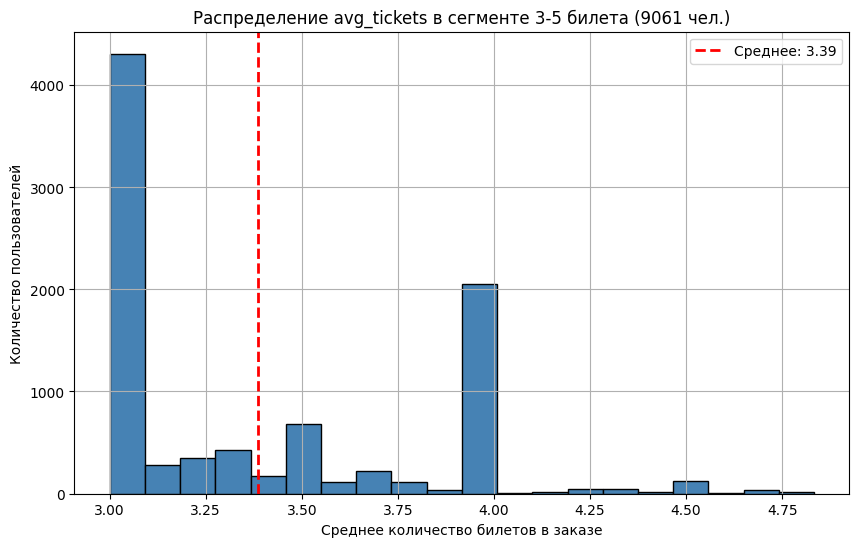

In [108]:
plt.figure(figsize=(10, 6))

plt.hist(tickets_3_5['avg_tickets'], bins=20,
         color='steelblue', edgecolor='black')

plt.axvline(tickets_3_5['avg_tickets'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Среднее: {tickets_3_5["avg_tickets"].mean():.2f}')

plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title(f'Распределение avg_tickets в сегменте 3-5 билета ({len(tickets_3_5)} чел.)')
plt.legend()
plt.grid()
plt.show()

In [109]:
tickets_5 = user_profile[(user_profile['avg_tickets'] >= 5)]

tickets_5['avg_tickets'].describe()

count    657.000000
mean       5.290985
std        0.596480
min        5.000000
25%        5.000000
50%        5.000000
75%        5.500000
max       11.000000
Name: avg_tickets, dtype: float64

In [110]:
size_5 = len(tickets_5)
percent_total_5 = (size_5 / len(user_profile))
return_rate_5 = tickets_5['is_two'].mean()
avg_revenue_5 = tickets_5['avg_revenue'].mean()

print(f'Количество пользователей: {size_5}')
print(f'Доля от всех пользователей: {percent_total_5}')
print(f'Доля повторных покупок: {return_rate_5}')
print(f'Средний чек: {avg_revenue_5}')

Количество пользователей: 657
Доля от всех пользователей: 0.030396964930137875
Доля повторных покупок: 0.1887366818873668
Средний чек: 828.2276788224613


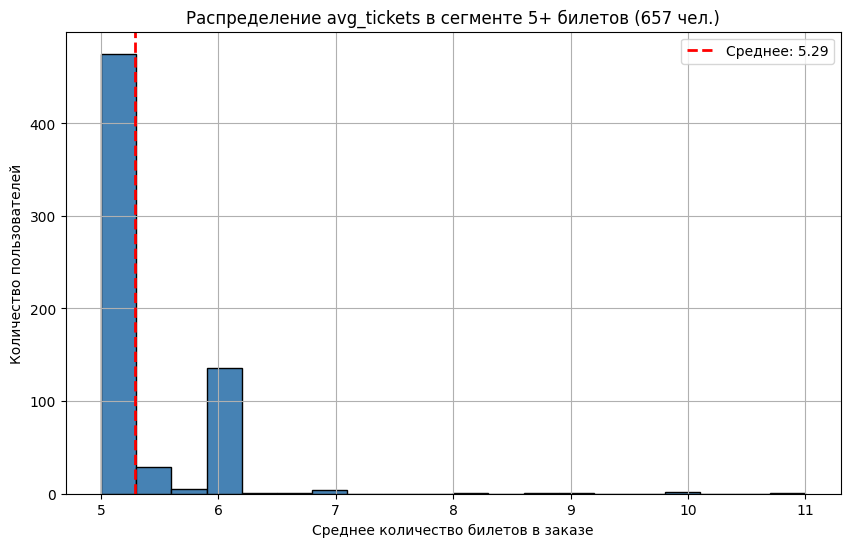

In [111]:
plt.figure(figsize=(10, 6))

plt.hist(tickets_5['avg_tickets'], bins=20,
         color='steelblue', edgecolor='black')

plt.axvline(tickets_5['avg_tickets'].mean(), color='red', linestyle='--',
            linewidth=2, label=f'Среднее: {tickets_5["avg_tickets"].mean():.2f}')

plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.title(f'Распределение avg_tickets в сегменте 5+ билетов ({len(tickets_5)} чел.)')
plt.legend()
plt.grid()
plt.show()

**Промежуточный вывод:**

По результатам можно сказать, что практически все пользователи концентрируются в диазоне от 2 до 4 билета, так как как там практически весь процент клиентов (43.9% и 41.9%). Пользователи, которые попали в сегменнт с 5+ билетами составляют 3%, количество пользователей - 657, это говорит о том, что их очень мало и они редки. Поэтому можно отметить крайне неравномерное распределение пользователей по сегментам.

Аномально высокий возврат можно увидеть в сегменте 2-3 билета - 73.6%, также сегмент является самым массовым (43.9%), эти пользователи являются лояльными.

Аномально низкий возврат в 5+ билетах - 18.9%.

Средний чек растет с увеличением количества билетов, самый высокий (5+ билетов) соответствует самой низкой лояльности.

Пользователи, покупающие 2-3 билета возвращаются чаще, потому что могут совершать заказы небольшие компании или семьи, которые чаще ходят на мероприятия вместе, а значит, лояльность у них выше. Клиенты с 5+ заказами, скорее всего выполняют разовые групповые покупки на большое количество людей, поэтому возвращаются реже.

---

#### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Временные параметры, связанные с первым заказом пользователей:

- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

---

**4.3.1.** Анализируем, как день недели, в которой была совершена первая покупка, влияет на поведение пользователей.

---


In [112]:
user_profile['weekday'] = user_profile['first_order_date'].dt.day_name()
user_profile['weekday_num'] = user_profile['first_order_date'].dt.dayofweek

weekday_stats = user_profile.groupby(['weekday_num', 'weekday']).agg(
    count=('user_id', 'count'),
    return_rate=('is_two', 'mean')
).reset_index()

weekday_stats['return_rate'] = (weekday_stats['return_rate'])
weekday_stats['percent'] = (weekday_stats['count'] / len(user_profile))

weekday_stats = weekday_stats.sort_values('weekday_num')

print(weekday_stats)

   weekday_num    weekday  count  return_rate   percent
0            0     Monday   2916     0.629973  0.134913
1            1    Tuesday   3175     0.618898  0.146896
2            2  Wednesday   3060     0.622549  0.141575
3            3   Thursday   3111     0.594664  0.143934
4            4     Friday   3255     0.597235  0.150597
5            5   Saturday   3321     0.627522  0.153650
6            6     Sunday   2776     0.600865  0.128435


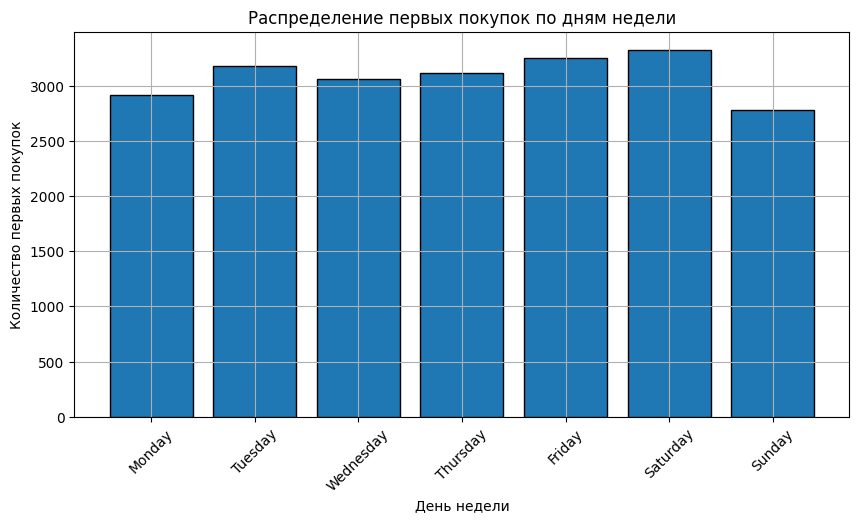

In [113]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_stats['weekday'],
        weekday_stats['count'],
        edgecolor='black')

plt.xlabel('День недели')
plt.ylabel('Количество первых покупок')
plt.title('Распределение первых покупок по дням недели')
plt.xticks(rotation=45)
plt.grid()

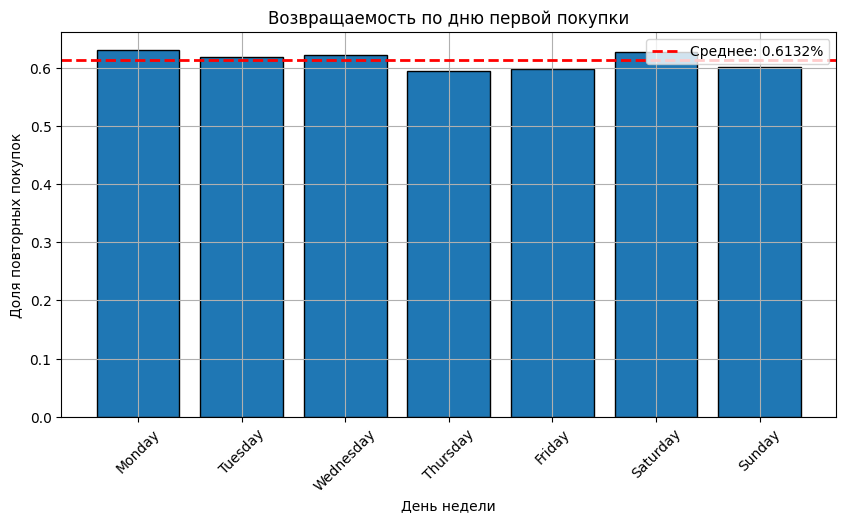

In [114]:
plt.figure(figsize=(10, 5))

plt.bar(weekday_stats['weekday'],
        weekday_stats['return_rate'],
        edgecolor='black')

plt.axhline(y=avg_return,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Среднее: {avg_return:.4f}%')

plt.xlabel('День недели')
plt.ylabel('Доля повторных покупок')
plt.title('Возвращаемость по дню первой покупки')
plt.xticks(rotation=45)
plt.legend()
plt.grid()

In [115]:
user_profile['lifetime'] = (user_profile['last_order_date'] - user_profile['first_order_date']).dt.days

user_profile['lifetime'] = user_profile['lifetime'].fillna(0).astype(int)

user_profile['lifetime'].describe()

count    21614.000000
mean        38.260479
std         51.579004
min          0.000000
25%          0.000000
50%          0.000000
75%         79.000000
max        152.000000
Name: lifetime, dtype: float64

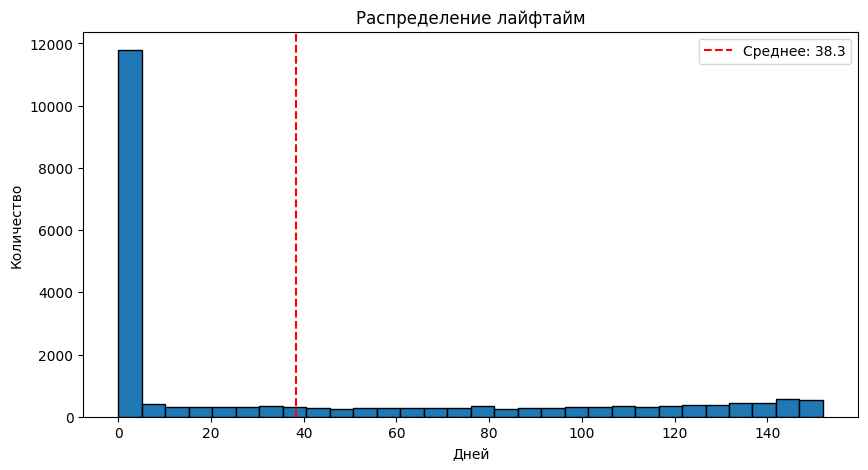

In [116]:
plt.figure(figsize=(10, 5))

plt.hist(user_profile['lifetime'],
         bins=30,
         edgecolor='black')
plt.axvline(user_profile['lifetime'].mean(), color='red', linestyle='--', label=f'Среднее: {user_profile["lifetime"].mean():.1f}')
plt.xlabel('Дней')
plt.ylabel('Количество')
plt.title('Распределение лайфтайм')
plt.legend()
plt.show()

In [117]:
intervals = user_profile[user_profile['is_two'] == 1]['days_since_prev']

print(f'Количество пользователей: {len(intervals)}')
print(f'Среднее: {intervals.mean():.2f} дней')
print(f'Медиана: {intervals.median()} дней')
print(f'min: {intervals.min()} дней')
print(f'max: {intervals.max()} дней')
print(f'25-75%: {intervals.quantile(0.25)} - {intervals.quantile(0.75)} дней')

Количество пользователей: 13253
Среднее: 15.33 дней
Медиана: 2.0 дней
min: 0.0 дней
max: 148.0 дней
25-75%: 0.0 - 19.0 дней


**Промежуточный вывод:**
* День недели первой покупки чаще выпадает на субботу 3324 - 62.8%. Реже всего - восресенье 2776 (60.1%).
* Средний возврат о выборке составляет 61.32%, максимальный возврат происходит в понедельник (63%) это выше среднего на 1.7%. Минимальный возврат: четверг (59.4%) — ниже среднего на 1.9%.
* Можно сделать вывод, что день недели первой покупки слабо влияет на вероятность возврата, это не является определяющим фактором. Разница составляет 3.6% между лучшим и худшим днем.
* Максимальное количество дней между покупкками составляет 152 дня. Большинство пользователей либо не возвращаются, либо возвращаются очень быстро, в течение 2 дней.
* Средний интервал между покуками у клиентов с повторными заказами составляет 15 дней, у некоторых клиентов - 0, пользователь совершал покупку сразу одну за другой.

---

**4.3.2.** Как средний интервал между заказами влияет на удержание клиентов?

- Среднее время между заказами для двух групп пользователей:
    - совершившие 2–4 заказа;
    - совершившие 5 и более заказов.
- Исследуем, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

---


In [118]:
intervals_2_4 = user_profile[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0)]['days_since_prev']
intervals_5plus = user_profile[user_profile['is_five'] == 1]['days_since_prev']

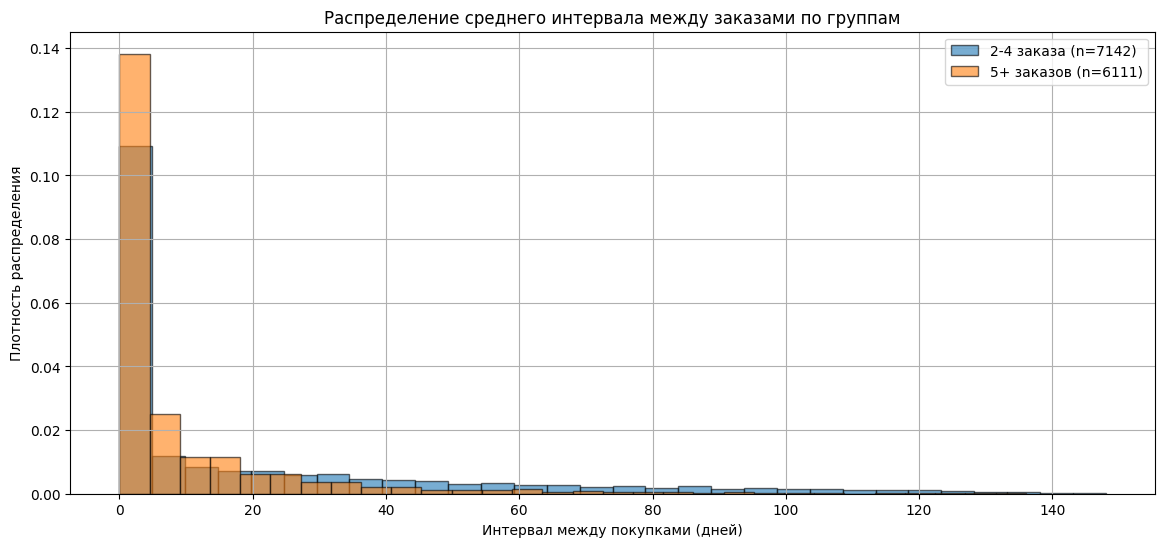

In [119]:
plt.figure(figsize=(14, 6))

# гистограмма для 2-4 заказов
plt.hist(intervals_2_4,
         bins=30,
         alpha=0.6,
         edgecolor='black',
         label=f'2-4 заказа (n={len(intervals_2_4)})', density=True)

# гистограмма для 5+ заказов
plt.hist(intervals_5plus,
         bins=30,
         alpha=0.6,
         edgecolor='black',
         label=f'5+ заказов (n={len(intervals_5plus)})', density=True)

plt.xlabel('Интервал между покупками (дней)')
plt.ylabel('Плотность распределения')
plt.title('Распределение среднего интервала между заказами по группам')
plt.legend()
plt.grid()
plt.show()

In [120]:
data = {
    'Группа': ['2-4 заказа', '5+ заказов'],
    'Количество пользователей': [len(intervals_2_4), len(intervals_5plus)],
    'Средний интервал между заказами (дни)': [intervals_2_4.mean(), intervals_5plus.mean()],
    'Медианный интервал между заказами (дни)': [intervals_2_4.median(), intervals_5plus.median()],
    'Стандартное отклонение': [intervals_2_4.std(), intervals_5plus.std()]
}
summary_table = pd.DataFrame(data)
print(summary_table)

       Группа  Количество пользователей  \
0  2-4 заказа                      7142   
1  5+ заказов                      6111   

   Средний интервал между заказами (дни)  \
0                              20.800336   
1                               8.936181   

   Медианный интервал между заказами (дни)  Стандартное отклонение  
0                                      2.0               32.147667  
1                                      1.0               16.983718  


**Промежуточный вывод:**

Средний интервал между заказами является ключевым фактором, по которому можно отследить насколько быстро клиент вернется. Клиенты с 5+ заказами возвращаются примерно через неделю - 8.9 дней. Порог значительно меньше, чем у пользователей с 2-4 заказа (20.79 дней). Разница в среднем интервале составляет почти 12 дней. Стандартное отклонение в группе 5+ заказов (16.99) почти в 2 раза меньше, это означает, что лояльные клиенты ведут себя предсказуемо, их интервалы между покупками более стабильны.

---

#### 4.4. Корреляционный анализ количества покупок и признаков пользователя

Какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок.

---

In [121]:
correlation_matrix = user_profile[['total_orders', 'first_order_date', 'last_order_date',
                                   'first_device', 'first_region', 'first_partner', 'first_genre',
                                   'avg_revenue', 'avg_tickets', 'days_since_prev']].phik_matrix()

print('Корреляционная матрица с коэффициентом phi_k для переменной total_orders')
total_orders_corr = correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']].sort_values(by='total_orders', ascending=False)
print(total_orders_corr)

interval columns not set, guessing: ['total_orders', 'avg_revenue', 'avg_tickets', 'days_since_prev']
Корреляционная матрица с коэффициентом phi_k для переменной total_orders
                  total_orders
first_order_date      0.429923
last_order_date       0.416228
avg_tickets           0.229955
avg_revenue           0.222722
days_since_prev       0.205449
first_region          0.124715
first_partner         0.037288
first_device          0.028352
first_genre           0.027187


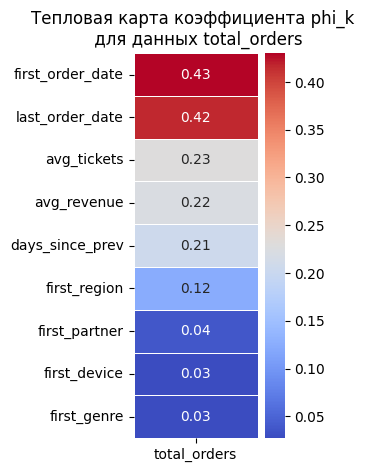


Самая сильная корреляция с рейтингом: first_order_date
Коэффициент Phi_k: 0.430


In [122]:
plt.figure(figsize=(2, 5))

data_heatmap = correlation_matrix[['total_orders']].loc[correlation_matrix.index != 'total_orders'].sort_values(by='total_orders', ascending=False)

sns.heatmap(
    data_heatmap,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True
)
plt.title('Тепловая карта коэффициента phi_k \n для данных total_orders')
plt.show()

strongest_corr_row = total_orders_corr.iloc[0]
strongest_feature = total_orders_corr.index[0]
strongest_value = strongest_corr_row['total_orders']

print(f'\nСамая сильная корреляция с рейтингом: {strongest_feature}')
print(f'Коэффициент Phi_k: {strongest_value:.3f}')

In [123]:
print(user_profile['total_orders'].value_counts().sort_index().head(10))
print(f"\nДоля пользователей с 1 заказом: {(user_profile['total_orders'] == 1).mean()}")

1     8361
2     3570
3     2171
4     1401
5      969
6      702
7      540
8      453
9      385
10     287
Name: total_orders, dtype: int64

Доля пользователей с 1 заказом: 0.3868326084944943


In [124]:
user_profile['order_segment'] = '1 заказ'

user_profile.loc[user_profile['is_five'] == 1, 'order_segment'] = '5+ заказов'
user_profile.loc[(user_profile['is_two'] == 1) & (user_profile['is_five'] == 0), 'order_segment'] = '2-4 заказа'
print(user_profile['order_segment'].value_counts())

1 заказ       8361
2-4 заказа    7142
5+ заказов    6111
Name: order_segment, dtype: int64


In [125]:
features = ['order_segment', 'avg_revenue', 'avg_tickets', 'days_since_prev',
            'first_device', 'first_region', 'first_partner', 'first_genre']

correlation_matrix = user_profile[features].phik_matrix()

segment_corr = correlation_matrix[['order_segment']].sort_values(by='order_segment', ascending=False)
segment_corr = segment_corr[segment_corr.index != 'order_segment']

print('\nКорреляция признаков с order_segment (1 заказ, 2-4, 5+):')
print(segment_corr.round(3))

interval columns not set, guessing: ['avg_revenue', 'avg_tickets', 'days_since_prev']

Корреляция признаков с order_segment (1 заказ, 2-4, 5+):
                 order_segment
avg_tickets              0.383
avg_revenue              0.326
days_since_prev          0.269
first_region             0.124
first_partner            0.079
first_genre              0.038
first_device             0.019


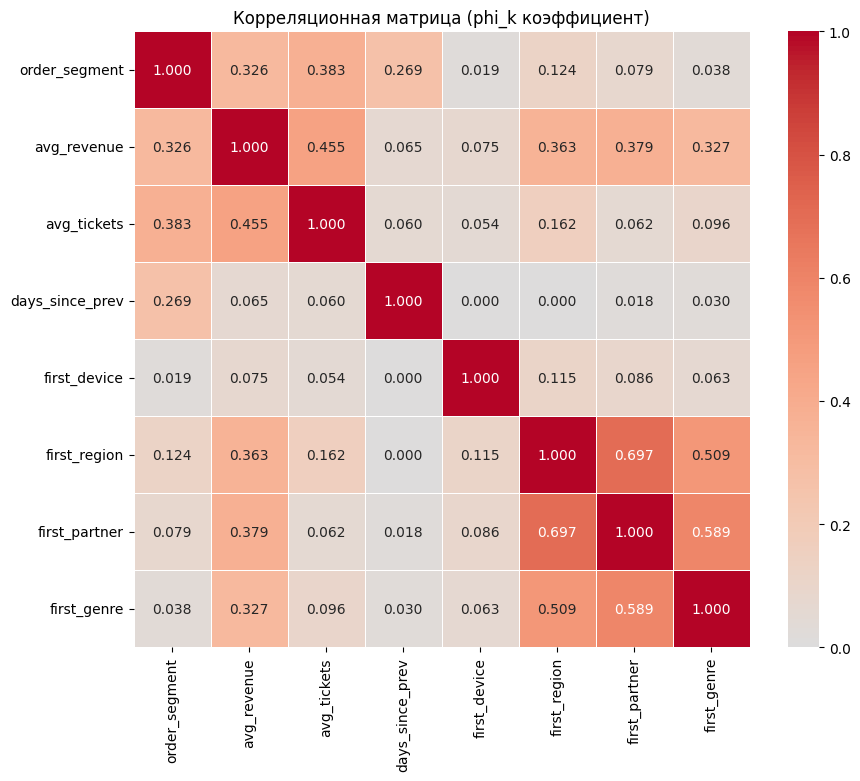

In [126]:
plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.3f',
            linewidths=0.5,
            cbar=True,
            cmap='coolwarm',
            center=0,
            square=True,
            xticklabels=True,
            yticklabels=True)

plt.title('Корреляционная матрица (phi_k коэффициент)')
plt.show()

**Промежуточный вывод:**

На основе корреляционного анализа с использованием коэффициента phi_k были выявлены признаки, которые наиболее сильно связаны с количеством заказов.
* days_since_prev `0.448`, это говорит о том, что чем меньше интервал между покупками, тем выше вероятность попадания пользователя в сегмент с большим количеством заказов.
* avg_tickets `0.383` - пользователи, покупающие больше билетов в одном заказе, демонстрируют более высокую лояльность, это говоорит о том, что большие заказы лучше удерживают пользователей.
* avg_revenue `0.328`, финонасовый показатель тоже имеет значение, но не такое сильное, как частота покупок и интервал между ними.

Все три признака (самые сильные) — days_since_prev, avg_tickets и avg_revenue — напрямую связаны с поведением клиента в процессе взаимодействия с сервисом: как часто он возвращается, сколько билетов берет, сколько тратит.

Данные, такие как устройство, жанр, регион, время и оператор имеют слабую связь. То есть на лояльность и на количество заказов эти факторы не влияют , не важно с какого устройства был оформлен заказ пользователем, на какое мероприятие он сходил и тд.

- **Информацию о данных:**

В ходе исследовательского анализа лояльности пользователей Яндекс Афиши, были изучены данные, которые получены при написании SQL-запроса для базы данных `data-analyst-afisha`. Общий датафрейм содержал 15 столбцов и 290611 записей. Пропуски на данном этапе содержались только в столбце days_since_prev (21933 7.55%). Он показывает, сколько дней, прошло между предыдущей и текущей покупками пользователя. NULL означает, что у пользователя только одна покупка, то есть первый заказ, пропуски оставляем, чтобы понимать наличие данного признака. Изначально данные о выручке сервиса были представлены в российских рублях и казахстанских тенге. В ходе работы над проектом произведен перевод к единой валюте — российскому рублю. Для этого был использован датасет с информацией о курсе казахстанского тенге по отношению к российскому рублю за 2024 год. После этого в столбце `revenue_rub` также появились значения с NULL, поэтому отфильтровали их по 99 перцентилю для дальнейшего анализа, также убрали отрицательные значения в столбце с выруской. В результате предобрадотки получилось удалить 251 (1.12) записей.


- **Основные результаты анализа:**

В процессе создания профиля пользователя в выборке оставить только необходимые столбцы, которые далее будут использоваться в анализе и также добавлены два новых `is_two` — информация совершил ли пользователь 2 и более заказа и `is_five` —  5 и более заказов. В итоговом датафрейме 13 столбцов и 21834 записи.
* Общее число пользователей в выборке 21614, is_two` (2+ заказов) 61.7% и `is_five` (5+) 29%. При подсчете статислических показателей по среднему количеству дней между покупками (2+ заказов), максимальное значение достигает 148 дней. После фильтрации в датафрейме удален 1.01% всех записей. В обновленном датасете user_profile 21614 строк, 13 колонок и занимает он 2.3+ MB. Отфильтрованы по 99-му перцентилю, удалено 220 записей (1.01%).
* Промежуточные данные показали, что клиенты чаще возвращаются в Яндекс Афишу, если покупают билеты на выставку с декстопного устройства из шанырского региона через оператора "край билетов". В топ-10 регионов вошли места с разницей около 1-2%. Первый в списке стоит шанырский регион 67% (+5.8% к среднему)
* Первая гипотеза о том, что тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты - не подтвердилать спортивные меропрятия - 56.1% и концерты - 61.8%.
* Гипотеза о том, что в регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах - не подтвердилась. Среднее по топ-5 активным регионам: 60.4%. Ниже чем среднее по выборке (61.3%)
* Связи между средней выручкой сервиса с заказа и повторными заказами не наблюдается, средние значения практически совпадают.
* Выяылены сегменты по среднему количеству билетов в заказе:
- от 1 до 2 билетов;
- от 2 до 3 билетов;
- от 3 до 5 билетов;
- от 5 и более билето
практически все пользователи концентрируются в диазоне от 2 до 4 билета, можно отметить крайне неравномерное распределение пользователей по сегментам. Аномально высокий возврат клиента на сервис можно увидеть в сегменте 2-3 билета - 73.6%,
* При анализе самого частого дня для покуок, практически все значения одинаковые, но при этом первая в списке стоит суббота 3324 - 62.8%
* Средний интервал между заказами является ключевым фактором, по которому можно отследить насколько быстро клиент вернется. Клиенты с 5+ заказами возвращаются примерно через неделю - 8.9 дней.
* Интервал между покупками влияет на лояльность клиентов, по матрице корелляции коэффициент равен 0.448. Вывод: чем меньше интервал между покупками, тем выше вероятность попадания пользователя в сегмент с большим количеством заказов.


- **Рекомендации:**


Необходимо держать фокус на самые лояльные сегменты и усилить коммуникацию в первые 2 дня после покупки, для клиентов, у которых большой интервал времени между заказами. Можно предложить им специальные условия, например, промокод или скидку на интересующее мероприятие, бонусы или баллы за повторный заказ в течение 2-3 дней. Необходимо повысить заинтересованность пользователей в приобретении билетов в будние дни, например, устроить акцию или розыгрыш.

Нет необходимости тратить ресурсы на сегментацию по устройству, жанру или региону — эти признаки слабо влияют на удержание.

Лояльность пользователей определяется не внешними факторами, а другими характеристиками: частотой покупок и размером заказа. Главная цель — сократить интервал между первой и второй покупкой до 2-3 дней.